In [2]:
%matplotlib inline 
import numpy as np 
from matplotlib import pyplot as plt 
import h5py # used in the Data Visualization section 
import pandas as pd

from astropy.io import fits,ascii,votable
from astropy import units as u 
from astropy import constants as const
from astropy import table
from astropy.cosmology import Planck15,FlatLambdaCDM

# For ML application
from sklearn.cluster import KMeans
from sklearn import mixture
from itertools import combinations

In [68]:
catversion = 'Classic'
fitversion = 'ez' 

In [168]:
flx = '_FLUX_APER2'  
flxerr = '_FLUXERR_APER2'  # catalog column for flux/mag error, just add 'ERR'
outflx = 'uJy'

In [70]:
# Filter names, mean wavelength, and other info (see Table 1 in W+21)
filt_name = ['GALEX_FUV', 'GALEX_NUV','CFHT_u','CFHT_ustar','HSC_g', 'HSC_r', 'HSC_i', 'HSC_z', 'HSC_y', 'UVISTA_Y', 'UVISTA_J', 'UVISTA_H', 'UVISTA_Ks', 'SC_IB427', 'SC_IB464', 'SC_IA484', 'SC_IB505', 'SC_IA527', 'SC_IB574', 'SC_IA624', 'SC_IA679', 'SC_IB709', 'SC_IA738', 'SC_IA767', 'SC_IB827', 'SC_NB711', 'SC_NB816', 'UVISTA_NB118', 'SC_B', 'SC_gp', 'SC_V', 'SC_rp', 'SC_ip','SC_zp', 'SC_zpp', 'IRAC_CH1', 'IRAC_CH2', 'IRAC_CH3','IRAC_CH4']  
filt_lambda = [0.1526,0.2307,0.3709,0.3858,0.4847,0.6219,0.7699,0.8894,0.9761,1.0216,1.2525,1.6466,2.1557,0.4266,0.4635,0.4851,0.5064,0.5261,0.5766,0.6232,0.6780,0.7073,0.7361,0.7694,0.8243,0.7121,0.8150,1.1909,0.4488,0.4804,0.5487,0.6305,0.7693,0.8978,0.9063,3.5686,4.5067,5.7788,7.9958]
filt_fwhm = [0.0224,0.07909,0.05181,0.05976,0.1383,0.1547,0.1471,0.0766,0.0786,0.0923,0.1718,0.2905,0.3074,0.02073,0.02182,0.02292,0.0231,0.02429,0.02729,0.03004,0.03363,0.03163,0.03235,0.03648,0.0343,0.0072,0.01198,0.01122,0.0892,0.1265,0.0954,0.1376,0.1497,0.0847,0.1335,0.7443,1.0119,1.4082,2.8796] 
# corresponding MW attenuation from Schelgel 
AlambdaDivEBV = [8.31,8.742,4.807,4.674,3.69,2.715,2.0,1.515,1.298,1.213,0.874,0.565,0.365,4.261,3.844,3.622,3.425,3.265,2.938,2.694,2.431,2.29,2.151,1.997,1.748,2.268,1.787,0.946,4.041,3.738,3.128,2.673,2.003,1.436,1.466,0.163,0.112,0.075,0.045]
# photometric offsets (not available for all filters, see Table 3 in W+21)
zpoff1 = [0.000,-0.352,-0.077,-0.023,0.073,0.101,0.038,0.036,0.086,0.054,0.017,-0.045,0.000,-0.104,-0.044,-0.021,-0.018,-0.045,-0.084,0.005,0.166,-0.023,-0.034,-0.032,-0.069,-0.010,-0.064,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.212,-0.219,0.000,0.000]  # Farmer+LePhare
zpoff2 = [0.000,-0.029,-0.006,0.053,0.128,0.127,0.094,0.084,0.100,0.049,0.025,-0.044,0.000,-0.013,-0.008,0.022,0.025,0.033,-0.032,0.031,0.208,-0.009,0.003,-0.015,-0.001,0.023,-0.021,-0.017,-0.075,0.000,0.123,0.035,0.051,0.000,0.095,-0.087,-0.111,0.000,0.000]  # Classic+LePhare
zpoff3 = [0.000,0.000,-0.196,-0.054,0.006,0.090,0.043,0.071,0.118,0.078,0.047,-0.034,0.000,-0.199,-0.129,-0.084,-0.073,-0.087,-0.124,0.004,0.154,-0.022,-0.030,-0.013,-0.057,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.102,-0.044,0.000,0.000] # Farmer+EAZY
zpoff4 = [0.000,0.000,0.000,-0.021,0.055,0.124,0.121,0.121,0.145,0.085,0.057,-0.036,0.000,-0.133,-0.098,-0.046,-0.037,-0.038,-0.062,0.038,0.214,0.024,0.022,0.01,0.022,0.000,0.000,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.021,0.025,0.000,0.000] # Classic+EAZY
# create the dictionary
filt_dict = {filt_name[i]:(filt_lambda[i]*1e4,filt_fwhm[i]*1e4,AlambdaDivEBV[i],[zpoff1[i],zpoff2[i],zpoff3[i],zpoff4[i]]) for i in range(len(filt_name))}

In [169]:
cat0 = table.Table.read('COSMOS2020_FARMER_R1_v2.2_p3.fits',format='fits',hdu=1)

In [174]:
whichflag = 'COMBINED'  # you can try HSC, SUPCAM, UVISTA, UDEEP, COMBINED
print('The parent sample includes {} sources'.format(len(cat0)))
cat0 = cat0[cat0['FLAG_{}'.format(whichflag)]==0]
print('Now restricted to {} sources by using FLAG_COMBINED'.format(len(cat0)))

The parent sample includes 964506 sources
Now restricted to 746976 sources by using FLAG_COMBINED


In [175]:
whichflag = 'UDEEP'  # you can try HSC, SUPCAM, UVISTA, UDEEP, COMBINED
print('The parent sample includes {} sources'.format(len(cat0)))
cat0 = cat0[cat0['FLAG_{}'.format(whichflag)]==0]
print('Now restricted to {} sources by using FLAG_UDEEP'.format(len(cat0)))

The parent sample includes 746976 sources
Now restricted to 424183 sources by using FLAG_UDEEP


In [176]:
mask = (cat0['ez_z_phot'] < 8)
cat0 = cat0[mask]
print(f"Now restricted to {len(cat0)} sources z < 8")

Now restricted to 361074 sources z < 8


In [178]:
df = cat0.to_pandas()
df1=df.copy()

In [179]:
df1 = df1.loc[:, ~df1.columns.str.contains("SPLASH")]

In [180]:
df1 = df1.loc[:, ~df1.columns.str.contains("lp")]
df1 = df1.loc[:, ~df1.columns.str.contains("ez")]

In [181]:
df1 = df1.loc[:, df1.columns.str.contains("FLUX")]

In [182]:
df1

,CFHT_u_FLUX,CFHT_u_FLUXERR,CFHT_ustar_FLUX,CFHT_ustar_FLUXERR,HSC_g_FLUX,HSC_g_FLUXERR,HSC_r_FLUX,HSC_r_FLUXERR,HSC_i_FLUX,HSC_i_FLUXERR,...,IRAC_CH3_FLUX,IRAC_CH3_FLUXERR,IRAC_CH4_FLUX,IRAC_CH4_FLUXERR,GALEX_NUV_FLUX,GALEX_NUV_FLUXERR,GALEX_FUV_FLUX,GALEX_FUV_FLUXERR,ACS_F814W_FLUX,ACS_F814W_FLUXERR
0,0.133153,0.004186,0.142804,0.003567,0.144235,0.003468,0.160328,0.004805,0.147505,0.004561,...,1.257470,0.454159,-2.450833,0.483782,NaN,NaN,0.114151,0.054075,0.025693,0.175130
1,0.029307,0.004178,0.028582,0.003543,0.040795,0.003462,0.060943,0.004745,0.060252,0.004515,...,1.816436,0.428299,0.901643,0.504945,NaN,NaN,NaN,NaN,NaN,NaN
2,0.082093,0.004143,0.076792,0.003589,0.155039,0.003334,0.174224,0.004816,0.145664,0.004557,...,-1.002099,0.420572,0.657565,0.504428,NaN,NaN,NaN,NaN,0.013530,0.139643
3,0.026649,0.004168,0.019983,0.003568,0.021123,0.003339,0.032121,0.004760,0.031603,0.004501,...,-1.071425,0.404526,2.611919,0.513863,NaN,NaN,NaN,NaN,NaN,NaN
4,0.002681,0.004112,0.008494,0.003478,0.043312,0.003226,0.057009,0.004613,0.052849,0.004384,...,0.186856,0.307740,-2.190073,0.381876,NaN,NaN,NaN,NaN,0.019549,0.056420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361069,0.003606,0.005777,NaN,NaN,-0.004635,0.003500,0.185986,0.004848,1.517658,0.004873,...,20.842425,0.457095,14.451977,0.502962,NaN,NaN,NaN,NaN,0.045931,2.732058
361070,1.189722,0.007262,NaN,NaN,1.604286,0.004743,1.904922,0.006245,3.090479,0.006782,...,5.074062,0.565992,6.457068,0.529517,0.601891,0.064773,0.037019,0.063240,0.074424,3.176604
361071,0.009685,0.004959,NaN,NaN,-0.031400,0.003112,-0.205230,0.004108,NaN,NaN,...,-1.117369,0.454306,3.429051,0.463625,NaN,NaN,NaN,NaN,0.024304,0.355585
361072,0.087109,0.005446,NaN,NaN,NaN,NaN,NaN,NaN,0.643498,0.005657,...,12.537979,0.467801,13.608021,0.529517,0.078516,0.058869,NaN,NaN,0.044776,1.612809


In [245]:
df1 = df1.loc[:, ~df1.columns.str.contains("RADIUS")]

In [246]:
df1 = df1.loc[:, ~df1.columns.str.contains("APER3")]
df1 = df1.loc[:, ~df1.columns.str.contains("AUTO")]

In [183]:
df1 = df1.loc[:, ~df1.columns.str.contains("ACS_F814")]
df1 = df1.loc[:, ~df1.columns.str.contains("CFHT_ustar")]

In [248]:
df1=df1.rename(columns={'IRAC_CH1_FLUX':'IRAC_CH1_FLUX_APER2','IRAC_CH1_FLUXERR':'IRAC_CH1_FLUXERR_APER2','IRAC_CH2_FLUX':'IRAC_CH2_FLUX_APER2','IRAC_CH2_FLUXERR':'IRAC_CH2_FLUXERR_APER2','GALEX_FUV_FLUX':'GALEX_FUV_FLUX_APER2','GALEX_FUV_FLUXERR':'GALEX_FUV_FLUXERR_APER2','GALEX_NUV_FLUX':'GALEX_NUV_FLUX_APER2','GALEX_NUV_FLUXERR':'GALEX_NUV_FLUXERR_APER2'})

In [249]:
filt_use=['CFHT_u', 'HSC_g', 'HSC_r',
       'HSC_i', 'HSC_z', 'HSC_y', 'UVISTA_Y',
       'UVISTA_J', 'UVISTA_H', 'UVISTA_Ks', 'UVISTA_NB118',
       'SC_IB427', 'SC_IB464', 'SC_IA484', 'SC_IB505',
       'SC_IA527', 'SC_IB574', 'SC_IA624', 'SC_IA679',
       'SC_IB709', 'SC_IA738', 'SC_IA767', 'SC_IB827',
       'SC_NB711', 'SC_NB816','SC_B','SC_gp','SC_V','SC_rp','SC_ip','SC_zp','SC_zpp', 'IRAC_CH1', 'IRAC_CH2', 'GALEX_NUV', 'GALEX_FUV']

In [250]:
fil=['cfht_u','hsc_g','hsc_r','hsc_i','hsc_z','hsc_y','subaru_suprimecam_B','subaru_suprimecam_V','sc_IB427','sc_IB464','subaru_suprimecam_ia484','sc_IB505','subaru_suprimecam_ia527','sc_IB574','subaru_suprimecam_ia624','subaru_suprimecam_ia679','sc_IB709','subaru_suprimecam_ia738',
 'subaru_suprimecam_ia767','sc_IB827','sc_NB711','sc_NB816','sc_gp','subaru_suprimecam_ip','subaru_suprimecam_zp','sc_zpp','subaru_suprimecam_rp','vista_vircam_H','vista_vircam_J','vista_vircam_Y','vista_vircam_Ks','nb118','galex_NUV','galex_FUV','irac_ch1','irac_ch2']

# Correction

In [251]:
len(filt_name)

39

In [252]:
def mw_corr(tab_in,f_dict,ebv_col=df['EBV_MW'],flx_col='_FLUX_APER2',flxerr_col='_FLUXERR_APER2',only_filt=[],skip_filt=[],verbose=False,out=False):
    if 'FLUX' in flx_col: flux=True
    else: flux=False
    if out: tab = tab_in.copy()
    else: tab = tab_in
    ff = f_dict.keys()
    if len(only_filt)>0 : ff = only_filt
    for c in ff:
        if verbose: print('remove MW attenuation in ',c+flx_col,f_dict[c][2])
        if c not in skip_filt:
            atten = f_dict[c][2]*ebv_col
            if flux:    tab[c+flx_col] *= np.power(10.,0.4*atten)
            else:    tab[c+flx_col] -= atten             
        else:
            if verbose: print('Skip filter',c)       
    if out: return tab

In [253]:
df1 = mw_corr(df1,filt_dict,flx_col=flx,flxerr_col=flxerr,only_filt=filt_use,out=True)

In [254]:
def aper_to_tot(tab_in,f_dict,flx_col='_FLUX_APER2',flxerr_col='_FLUXERR_APER2',scale_col='',out_col=None,only_filt=[],skip_filt=[],verbose=False,out=False):

    if 'FLUX' in flx_col: flux=True
    else: flux=False
    if out: tab = tab_in.copy()
    else: tab = tab_in 
    ff = f_dict.keys()
    if len(only_filt)>0 : ff = only_filt
    for c in ff:
        if c not in skip_filt:

            if verbose and flux: print('rescale {} to total flux'.format(c+flx_col))
            if verbose and not flux: print('rescale {} to total mag'.format(c+flx_col))

            if flux:
                resc = np.power(10.,-0.4*df[scale_col])
                if out_col:
                    tab[c+out_col] = tab[c+flx_col] * resc
                    tab[c+out_col+'ERR'] = tab[c+flxerr_col] * resc  # rescale also error bars not to alter the S/N ratio
                else:
                    tab[c+flx_col] *= resc
                    tab[c+flxerr_col] *= resc
            else:
                if out_col:
                    tab[c+out_col] = tab[c+flx_col] + df[scale_col] 
                else:
                    tab[c+flx_col] += df[scale_col]             
        else:
            if verbose: print('Skip filter',c)       
    if out: return tab

In [256]:
if (flx[-1]=='2' or flx[-1]=='3'):
    aper_to_tot(df1,filt_dict,flx_col=flx,flxerr_col=flxerr,out_col='_FLUX',
    only_filt=filt_use,
    scale_col='total_off'+flx[-1],verbose=False)

In [257]:
#df1[df1 < 0] = 0
df1

,CFHT_u_FLUX_APER2,CFHT_u_FLUXERR_APER2,HSC_g_FLUX_APER2,HSC_g_FLUXERR_APER2,HSC_r_FLUX_APER2,HSC_r_FLUXERR_APER2,HSC_i_FLUX_APER2,HSC_i_FLUXERR_APER2,HSC_z_FLUX_APER2,HSC_z_FLUXERR_APER2,...,SC_zpp_FLUX,SC_zpp_FLUXERR,IRAC_CH1_FLUX,IRAC_CH1_FLUXERR,IRAC_CH2_FLUX,IRAC_CH2_FLUXERR,GALEX_NUV_FLUX,GALEX_NUV_FLUXERR,GALEX_FUV_FLUX,GALEX_FUV_FLUXERR
0,0.018518,0.010018,0.022999,0.006894,0.043978,0.010408,0.087923,0.013783,0.111448,0.021368,...,0.064619,0.053450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.045069,0.008940,0.080667,0.007487,0.151107,0.011148,0.147975,0.013603,0.185267,0.020803,...,0.168344,0.047368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.048137,0.008683,0.127222,0.008072,0.176518,0.011204,0.167256,0.013734,0.171301,0.021360,...,0.197251,0.044935,0.643643,0.033546,0.684665,0.064778,NaN,NaN,NaN,NaN
3,0.038645,0.009557,0.043549,0.006454,0.069189,0.008581,0.078928,0.010292,0.084418,0.016197,...,0.101409,0.038326,0.626008,0.009654,NaN,NaN,NaN,NaN,NaN,NaN
4,0.004803,0.008998,-0.008603,0.006035,0.003189,0.008247,0.065881,0.010326,0.077828,0.016419,...,0.081329,0.040362,0.235905,0.016214,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381611,1.331021,0.010422,4.667025,0.026311,14.374746,0.044929,23.290965,0.051603,33.017741,0.071846,...,57.290195,0.066417,135.333747,0.539424,131.706207,0.433332,0.838312,0.086894,0.165371,0.077218
381612,2.901970,0.010521,16.443001,0.048906,48.362025,0.082019,75.123941,0.092154,97.447718,0.122306,...,335.898773,0.158204,995.022329,1.122515,783.614256,0.821730,5.087938,0.269545,4.075334,0.321917
381613,0.232899,0.010694,0.334970,0.008591,0.444649,0.009916,0.680019,0.011299,0.909644,0.016736,...,1.162821,0.035063,11.411543,0.076219,12.546194,0.096182,NaN,NaN,NaN,NaN
381614,1.959154,0.012061,3.654884,0.024126,7.167601,0.033028,8.455598,0.033719,10.706203,0.045063,...,25.292144,0.097333,41.612652,0.314581,41.328166,0.474411,8.751306,0.201405,5.139489,0.226322


In [258]:
def photo_corr(tab_in,f_dict,versions=('Farmer','lp'),flx_col='_FLUX',only_filt=[],skip_filt=[],verbose=False,out=False):
    """
    Parameters
    ----------
    tab_in : astropy table of COSMOS2020
    f_dict : dictionary with filter info
    ebv_col : name of the `tab_in` column containing the E(B-V) from Milky Way
    flx_col : name of the `tab_in` column containing the flux
    flxerr_col : name of the `tab_in` column containing the flux error bar
    only_filt : list of the filters to be processed (filter names as in `f_dict`)
    skip_filt : list of the filters NOT to be processed (filter names as in `f_dict`)
    verbose : if True, print a verbose output
    out : if True, return a new table with the changes; if False, overwrite `tab_in`
    """
    if 'FLUX' in flx_col: flux=True
    else: flux=False
    if out: tab = tab_in.copy()
    else: tab = tab_in
    ff = f_dict.keys()
    if len(only_filt)>0 : ff = only_filt
    
    if versions[0]=='Farmer' and versions[1]=='lp': v=0
    elif versions[0]=='Farmer' and versions[1]=='ez': v=1
    elif versions[0]=='Classic' and versions[1]=='lp': v=2
    elif versions[0]=='Classic' and versions[1]=='ez': v=3
    else: 
        print("ERROR: is this catalog version real?", version)
        return
    
    for c in ff:
        if verbose: print(' apply photometric offset to ',c+flx_col)
        offset = f_dict[c][3][v]
        if c not in skip_filt and offset!=0.:
            if flux:  tab[c+flx_col] *= np.power(10.,-0.4*offset)
            else:  tab[c+flx_col] += offset              
        else:
            if verbose: print('Skip filter',c)       
    if out: return tab

In [259]:
fitversion = 'ez' 
photo_corr(df1,filt_dict,only_filt=filt_use,versions=(catversion,fitversion))

In [184]:
df1_flux=df1.loc[:, ~df1.columns.str.contains("FLUXERR")]

In [185]:
df1_err=df1.loc[:, df1.columns.str.contains("FLUXERR")]

In [186]:
df1_flux

,CFHT_u_FLUX,HSC_g_FLUX,HSC_r_FLUX,HSC_i_FLUX,HSC_z_FLUX,HSC_y_FLUX,UVISTA_Y_FLUX,UVISTA_J_FLUX,UVISTA_H_FLUX,UVISTA_Ks_FLUX,...,SC_IA767_FLUX,SC_IB827_FLUX,SC_NB711_FLUX,SC_NB816_FLUX,IRAC_CH1_FLUX,IRAC_CH2_FLUX,IRAC_CH3_FLUX,IRAC_CH4_FLUX,GALEX_NUV_FLUX,GALEX_FUV_FLUX
0,0.133153,0.144235,0.160328,0.147505,0.163531,0.214883,0.225864,0.346827,0.372447,0.323766,...,0.120971,0.055384,0.196474,0.126831,0.199715,0.324382,1.257470,-2.450833,NaN,0.114151
1,0.029307,0.040795,0.060943,0.060252,0.062392,0.045269,0.115621,0.034069,0.105598,0.055944,...,-0.043090,0.060826,0.126346,0.081364,-0.141102,-0.106596,1.816436,0.901643,NaN,NaN
2,0.082093,0.155039,0.174224,0.145664,0.139591,0.126580,0.065966,0.078777,0.308426,0.201543,...,0.172516,0.087776,0.174551,0.147894,0.047686,0.076376,-1.002099,0.657565,NaN,NaN
3,0.026649,0.021123,0.032121,0.031603,0.035563,0.056480,0.069294,0.098300,0.091572,0.065444,...,0.000605,0.049655,-0.086482,0.034247,0.015345,0.104036,-1.071425,2.611919,NaN,NaN
4,0.002681,0.043312,0.057009,0.052849,0.046557,0.019379,0.032118,0.047465,0.084997,0.175088,...,0.088280,0.005919,0.054976,0.024663,-0.132267,-0.071168,0.186856,-2.190073,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361069,0.003606,-0.004635,0.185986,1.517658,4.065788,6.520903,7.440210,NaN,NaN,NaN,...,1.025064,2.563994,NaN,NaN,43.682880,32.903468,20.842425,14.451977,NaN,NaN
361070,1.189722,1.604286,1.904922,3.090479,3.666506,4.654343,4.718836,NaN,NaN,NaN,...,2.323263,2.576893,NaN,NaN,6.903381,6.980788,5.074062,6.457068,0.601891,0.037019
361071,0.009685,-0.031400,-0.205230,NaN,NaN,NaN,0.125112,NaN,NaN,NaN,...,NaN,-0.371660,NaN,NaN,1.468984,0.919922,-1.117369,3.429051,NaN,NaN
361072,0.087109,NaN,NaN,0.643498,1.886475,2.888071,3.213008,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,20.514880,17.498909,12.537979,13.608021,0.078516,NaN


In [33]:
df.to_feather('original.feather')
df_flux.to_feather('flux.feather')
df_err.to_feather('error.feather')

In [3]:
df_flux = pd.read_feather("flux.feather")
df_err = pd.read_feather("error.feather")
df = pd.read_feather("original.feather")

In [56]:
df_flux=df_flux.drop(['CFHT_ustar_FLUX_APER2','SC_B_FLUX_APER2','SC_gp_FLUX_APER2','SC_V_FLUX_APER2','SC_rp_FLUX_APER2','SC_ip_FLUX_APER2','SC_zp_FLUX_APER2','SC_zpp_FLUX_APER2','GALEX_FUV_FLUX_APER2','GALEX_NUV_FLUX_APER2' ], axis=1)
df_err=df_err.drop(['CFHT_ustar_FLUXERR_APER2','SC_B_FLUXERR_APER2','SC_gp_FLUXERR_APER2','SC_V_FLUXERR_APER2','SC_rp_FLUXERR_APER2','SC_ip_FLUXERR_APER2','SC_zp_FLUXERR_APER2','SC_zpp_FLUXERR_APER2','GALEX_FUV_FLUXERR_APER2','GALEX_NUV_FLUXERR_APER2' ], axis=1)

In [57]:
df_flux=df_flux.iloc[:, [0,10,11,1,12,13,14,2,15,16,17,3,18,19,20,21,22,23,4,5,6,7,8,9,25,26]]
df_err=df_err.iloc[:, [0, 10,11,1,12,13,14,2,15,16,17,3,18,19,20,21,22,23,4,5,6,7,8,9,25,26]]

In [58]:
df_flux.columns

Index(['CFHT_u_FLUX_APER2', 'SC_IB427_FLUX_APER2', 'SC_IB464_FLUX_APER2',
       'HSC_g_FLUX_APER2', 'SC_IA484_FLUX_APER2', 'SC_IB505_FLUX_APER2',
       'SC_IA527_FLUX_APER2', 'HSC_r_FLUX_APER2', 'SC_IB574_FLUX_APER2',
       'SC_IA624_FLUX_APER2', 'SC_IA679_FLUX_APER2', 'HSC_i_FLUX_APER2',
       'SC_IB709_FLUX_APER2', 'SC_IA738_FLUX_APER2', 'SC_IA767_FLUX_APER2',
       'SC_IB827_FLUX_APER2', 'SC_NB711_FLUX_APER2', 'SC_NB816_FLUX_APER2',
       'HSC_z_FLUX_APER2', 'HSC_y_FLUX_APER2', 'UVISTA_Y_FLUX_APER2',
       'UVISTA_J_FLUX_APER2', 'UVISTA_H_FLUX_APER2', 'UVISTA_Ks_FLUX_APER2',
       'IRAC_CH1_FLUX_APER2', 'IRAC_CH2_FLUX_APER2'],
      dtype='object')

In [60]:
len(df_flux.columns)

26

## Model

In [9]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

# Files
files = glob('fsps/*')
wave_grid = np.linspace(800, 50000, 20000)
dlam = np.gradient(wave_grid)   # needed for proper L1
flux_interp_L1 = {}
c_angstrom = 2.99792458e18 

for idx, fname in enumerate(files):
    wave, flux_lam = np.loadtxt(fname, unpack=True)
    flux_lam_interp = np.interp(wave_grid, wave, flux_lam)

    flux_nu_interp = flux_lam_interp * (wave_grid**2) / c_angstrom
    nu_grid = c_angstrom / wave_grid
    dnu = np.abs(np.gradient(nu_grid))
    
    area = np.sum(flux_nu_interp * dnu)
    flux_L1 = flux_nu_interp / area
    flux_interp_L1[fname] = flux_L1


In [10]:
flux_list = []
for name in flux_interp_L1.keys():
    flux_list.append(flux_interp_L1[name])

X = np.array(flux_list)

In [11]:
from sklearn.decomposition import NMF
model = NMF(4, init='random', random_state=0)
W = model.fit_transform(X)
H = model.components_

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


# Conditional Probablity Algorithm

In [59]:
from sedpy.observate import getSED, load_filters

fil=['cfht_u','sc_IB427','sc_IB464','hsc_g','subaru_suprimecam_ia484','sc_IB505','subaru_suprimecam_ia527','hsc_r','sc_IB574','subaru_suprimecam_ia624','subaru_suprimecam_ia679','hsc_i','sc_IB709','subaru_suprimecam_ia738',
    'subaru_suprimecam_ia767','sc_IB827','sc_NB711','sc_NB816','hsc_z','hsc_y','vista_vircam_Y','vista_vircam_J','vista_vircam_H','vista_vircam_Ks','irac_ch1','irac_ch2']

filters = load_filters(fil)


--- EM for Redshift-Dependent Coeff Mean & Separate Redshift Mean ---

[Diagnostics] Plotting b_i for iteration 1...



<Figure size 640x480 with 0 Axes>

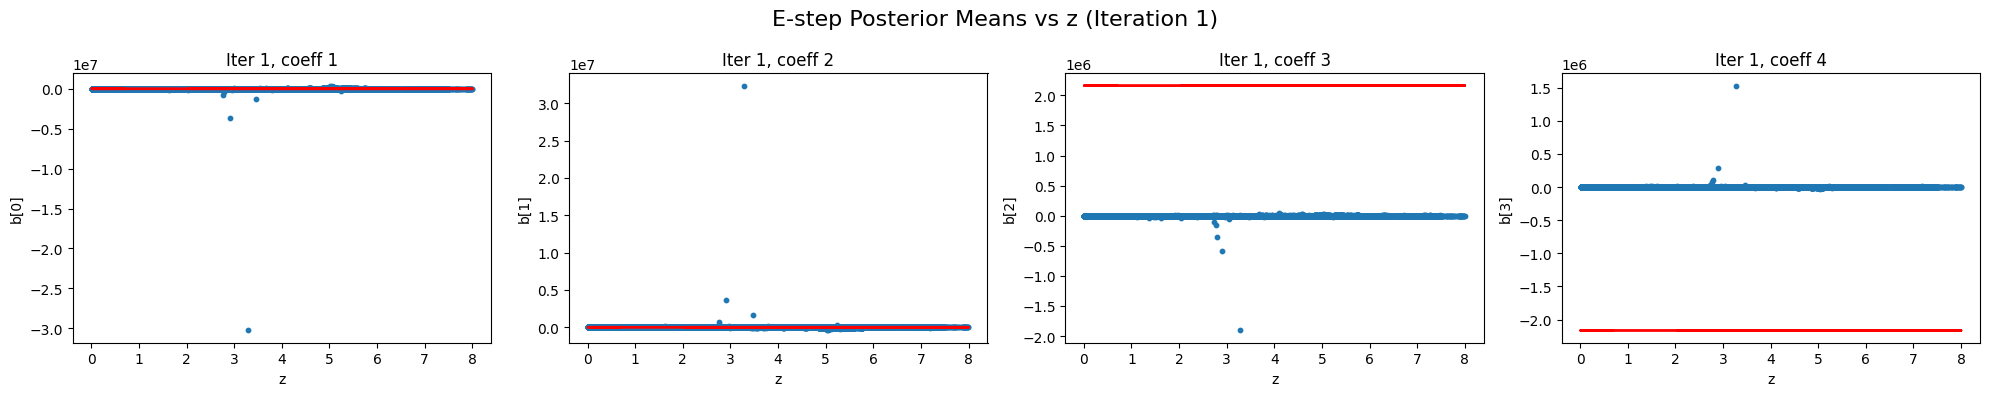

Iter 01 | ΔM = 3.061e+06 | time = 8.3s
[ 230.53225154 -152.58781382   65.12462757  -31.02439069]
Iter 02 | ΔM = 2.283e+02 | time = 4.3s
[ 26.19963739 -29.01864202   0.28576474  -0.67902561]
Iter 03 | ΔM = 5.401e+01 | time = 5.2s
[-5.87206272  3.27114087 -0.30755486  0.55239542]
Iter 04 | ΔM = 3.006e+01 | time = 11.6s
[-3.35496157  1.30995568 -0.17546863  0.31767712]
Iter 05 | ΔM = 1.673e+01 | time = 11.2s
[-1.89587295  0.7309077  -0.10205179  0.18380374]
Iter 06 | ΔM = 9.400e+00 | time = 10.5s
[-1.06829438  0.45674247 -0.05851101  0.1049427 ]
Iter 07 | ΔM = 5.259e+00 | time = 6.2s
[-0.59698859  0.28143932 -0.03292312  0.05890593]
Iter 08 | ΔM = 2.920e+00 | time = 6.3s
[-0.3309555   0.16733965 -0.01830616  0.03266186]
Iter 09 | ΔM = 1.610e+00 | time = 5.4s
[-0.18229981  0.0964692  -0.01007023  0.01796296]

[Diagnostics] Plotting b_i for iteration 10...



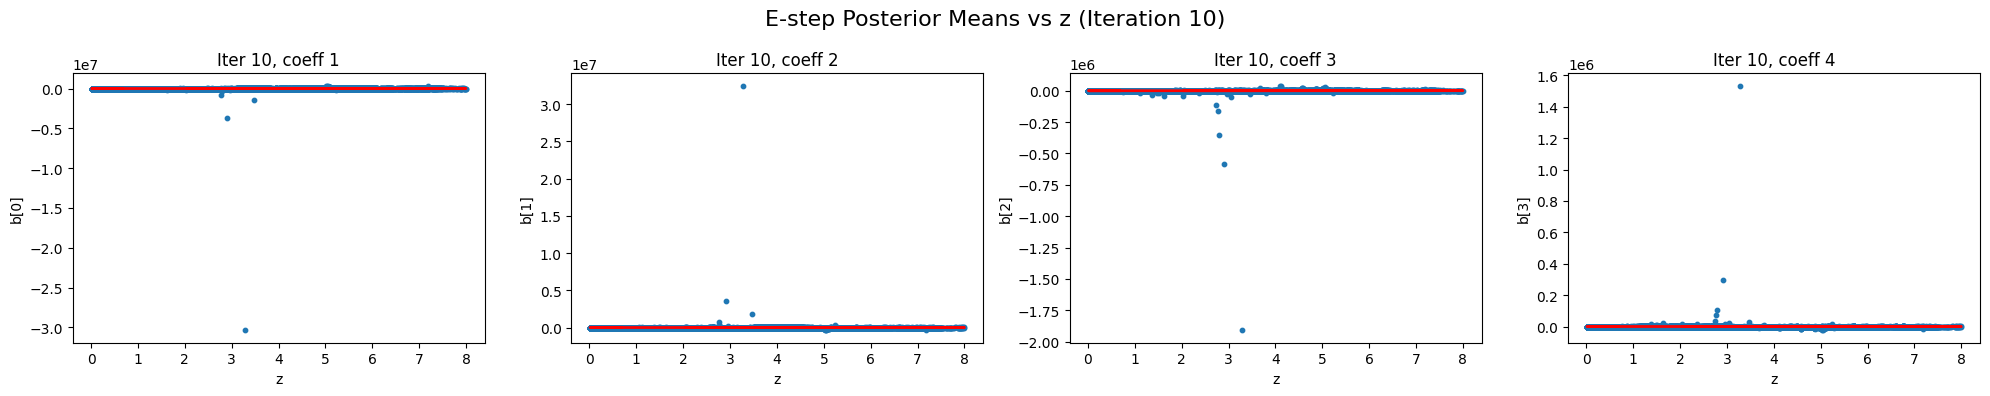

Iter 10 | ΔM = 8.835e-01 | time = 10.3s
[-0.09994626  0.05443271 -0.00551161  0.00983098]
Iter 11 | ΔM = 4.831e-01 | time = 10.4s
[-0.05462599  0.030286   -0.00300898  0.00536531]
Iter 12 | ΔM = 2.636e-01 | time = 12.6s
[-0.0297923   0.01669583 -0.00163952  0.00292322]
Iter 13 | ΔM = 1.436e-01 | time = 10.2s
[-0.01623163  0.00916114 -0.00090019  0.00159278]
Iter 14 | ΔM = 7.817e-02 | time = 11.0s
[-0.00883314  0.00499896 -0.00048596  0.00086585]
Iter 15 | ΔM = 4.253e-02 | time = 9.9s
[-0.00480534  0.00272583 -0.00026408  0.00047086]
Iter 16 | ΔM = 2.313e-02 | time = 10.6s
[-0.00261387  0.00148497 -0.00014391  0.00025611]
Iter 17 | ΔM = 1.258e-02 | time = 11.1s
[-1.42101341e-03  8.07758515e-04 -7.82343730e-05  1.39230606e-04]
Iter 18 | ΔM = 6.836e-03 | time = 10.1s
[-7.73084009e-04  4.40209409e-04 -4.33067547e-05  7.58577275e-05]
Iter 19 | ΔM = 3.718e-03 | time = 9.8s
[-4.20085655e-04  2.38790585e-04 -2.31345408e-05  4.11686041e-05]

[Diagnostics] Plotting b_i for iteration 20...



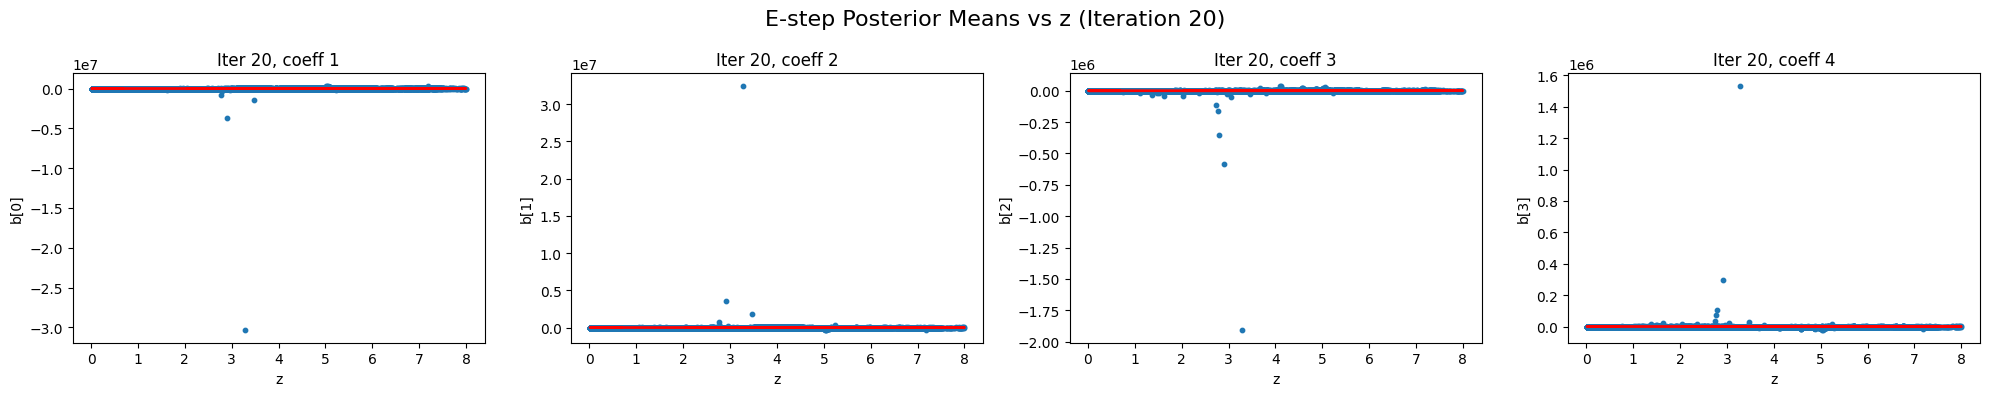

Iter 20 | ΔM = 2.021e-03 | time = 14.3s
[-2.28356619e-04  1.29936823e-04 -1.25293042e-05  2.23618263e-05]
Iter 21 | ΔM = 1.099e-03 | time = 10.6s
[-1.24214580e-04  7.07324874e-05 -6.97372946e-06  1.21889873e-05]
Iter 22 | ΔM = 5.965e-04 | time = 10.0s
[-6.74145487e-05  3.83653071e-05 -3.71001978e-06  6.60616283e-06]
Iter 23 | ΔM = 3.245e-04 | time = 11.1s
[-3.66710737e-05  2.08509868e-05 -2.01889300e-06  3.59391283e-06]
Iter 24 | ΔM = 1.767e-04 | time = 7.4s
[-1.99972300e-05  1.14200461e-05 -1.09705893e-06  1.95408125e-06]
Iter 25 | ΔM = 9.598e-05 | time = 4.6s
[-1.08759829e-05  6.26712489e-06 -5.94690417e-07  1.05935796e-06]
Iter 26 | ΔM = 5.220e-05 | time = 6.4s
[-5.94248082e-06  3.49229401e-06 -3.21098272e-07  5.72512769e-07]
Iter 27 | ΔM = 2.806e-05 | time = 4.3s
[-3.14966986e-06  1.77545674e-06 -1.74924207e-07  3.11606592e-07]
Iter 28 | ΔM = 1.538e-05 | time = 4.4s
[-1.73421835e-06  1.07774226e-06 -9.17106246e-08  1.63288481e-07]
Iter 29 | ΔM = 8.246e-06 | time = 4.3s
[-9.07859857

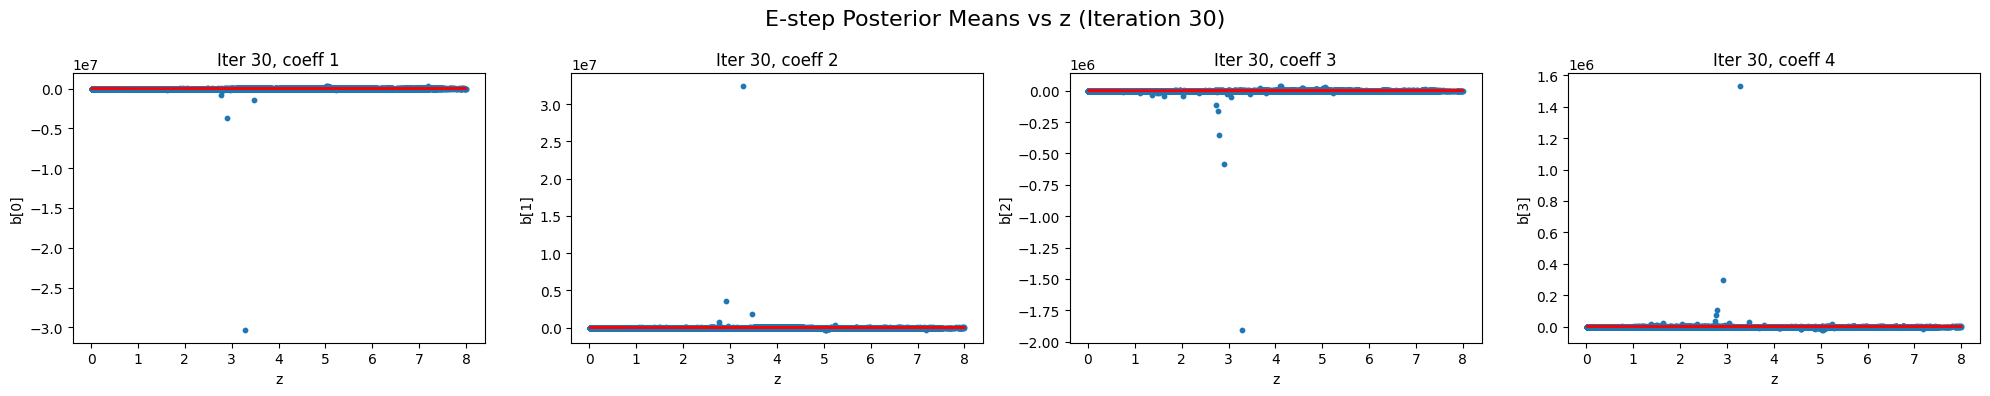

Iter 30 | ΔM = 4.536e-06 | time = 7.8s
[-5.28812465e-07  3.27252766e-07 -2.77350525e-08  4.94384148e-08]
Iter 31 | ΔM = 2.790e-06 | time = 4.5s
[-3.93746061e-07  2.93379521e-07 -1.73743767e-08  3.09948594e-08]
Iter 32 | ΔM = 9.166e-07 | time = 5.4s
[-5.56415331e-08  1.35171790e-07 -8.86549729e-11  5.06236955e-10]
Iter 33 | ΔM = 6.169e-07 | time = 4.2s
[ 2.90352865e-08 -2.65070739e-07 -1.03940159e-08  1.75477645e-08]
Iter 34 | ΔM = 3.032e-07 | time = 5.1s
[ 4.07606764e-08 -1.72852103e-07 -4.61254511e-09  8.42863853e-09]
Iter 35 | ΔM = 6.346e-07 | time = 10.4s
[-9.59691092e-08  4.68154698e-08 -4.61152261e-09  8.33766900e-09]
Iter 36 | ΔM = 4.626e-07 | time = 4.3s
[-1.20502525e-07  2.07307223e-07  5.16775184e-10 -5.80255588e-10]
Iter 37 | ΔM = 1.472e-07 | time = 4.2s
[ 2.33400829e-08  1.13122466e-08  1.58244659e-09 -3.09754668e-09]
Iter 38 | ΔM = 1.808e-07 | time = 4.2s
[-2.43603482e-08 -3.71495344e-08 -3.07486870e-09  5.38810054e-09]
Iter 39 | ΔM = 1.901e-07 | time = 5.0s
[ 1.50112748e-0

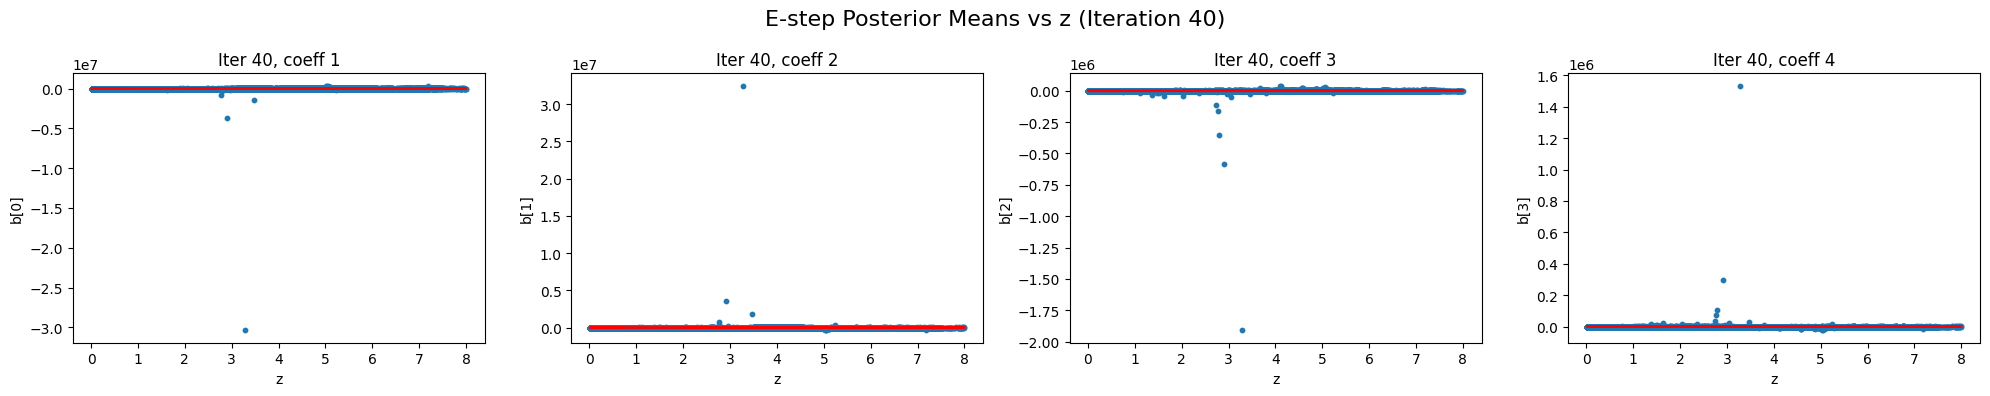

Iter 40 | ΔM = 2.282e-07 | time = 6.5s
[-3.35639071e-08 -9.33444981e-08 -5.95678401e-09  9.97316980e-09]
Iter 41 | ΔM = 2.517e-07 | time = 4.9s
[ 6.19213406e-08  4.15073553e-08  6.31560782e-09 -1.05053767e-08]
Iter 42 | ΔM = 2.372e-07 | time = 4.2s
[ 3.83018786e-08 -1.81262893e-07 -5.54281648e-09  9.27732863e-09]
Iter 43 | ΔM = 6.779e-08 | time = 4.0s
[-1.58554904e-09  4.45761446e-08  2.03446334e-09 -3.20305502e-09]
Iter 44 | ΔM = 1.857e-07 | time = 5.9s
[ 6.86092527e-08 -1.37398400e-07 -1.74955238e-09  2.53604327e-09]
Iter 45 | ΔM = 4.519e-07 | time = 10.8s
[-1.01304111e-07 -1.13414658e-08 -6.65045065e-09  1.15719764e-08]
Iter 46 | ΔM = 3.087e-07 | time = 10.4s
[ 3.58033488e-08  1.10261046e-07  6.70453717e-09 -1.10495160e-08]
Iter 47 | ΔM = 2.489e-07 | time = 6.5s
[-2.45950392e-08 -3.83623166e-08 -2.97952707e-09  4.92922689e-09]
Iter 48 | ΔM = 1.615e-07 | time = 4.7s
[-3.11876254e-08  1.28615806e-07  3.39106636e-09 -5.49617461e-09]
Iter 49 | ΔM = 2.455e-07 | time = 4.6s
[-9.74605250e-

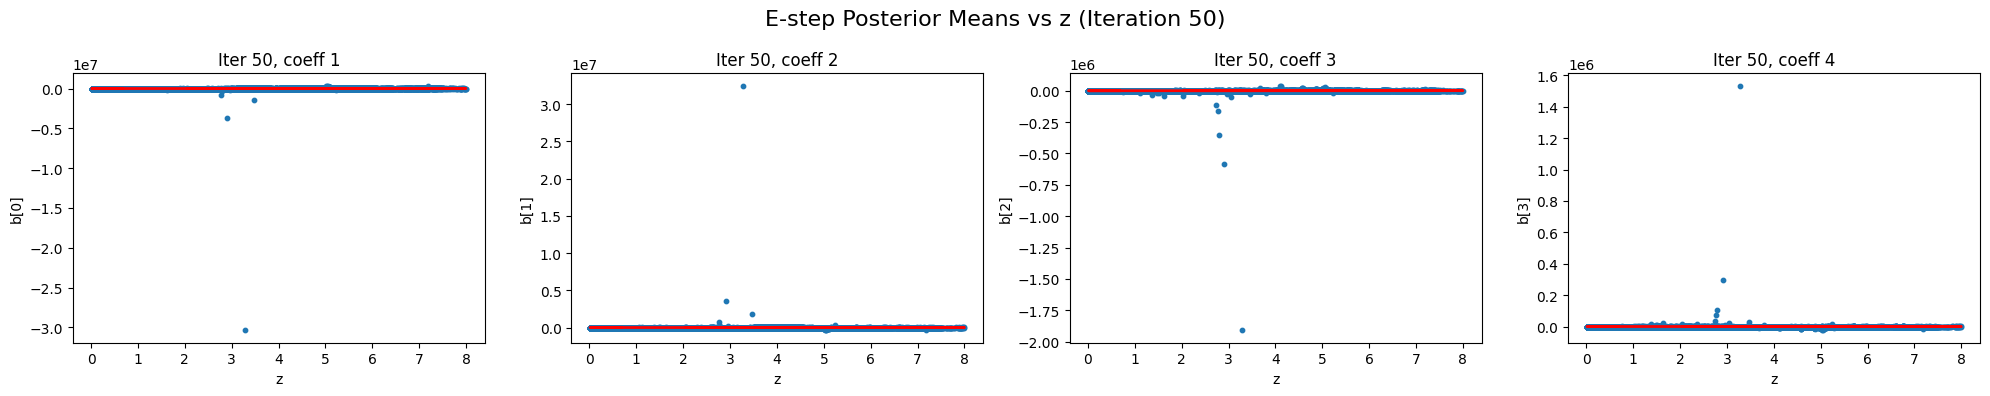

Iter 50 | ΔM = 3.228e-07 | time = 11.1s
[ 3.36953416e-08  4.60651098e-08  4.20465486e-09 -7.02528382e-09]

--- Fit Complete ---
Final M0c: [-569.29888509  513.6842907   -70.87145725   54.08432417]
Final M1c: [ 550.30447093 -466.55473136   91.81670795  -57.22950125]
Final Sigma_c: [[ 2.74579116e+07  2.62138873e+08 -2.86723365e+09  2.57781146e+09]
 [ 2.62138873e+08  7.26769631e+09 -2.27451561e+11  2.19925556e+11]
 [-2.86723365e+09 -2.27451561e+11  2.72675200e+17 -2.72674970e+17]
 [ 2.57781146e+09  2.19925556e+11 -2.72674970e+17  2.72674748e+17]]


In [61]:
import numpy as np
import pandas as pd
from sedpy.observate import getSED, load_filters
from scipy.interpolate import RegularGridInterpolator
import time
import matplotlib.pyplot as plt
plt.clf()

f_all = np.load('pcaflux_w_redshift1.npy')   # shape: (Nz, Kc, Nbands)
z_grid1=np.load('zgrid.npy')
f_interp_vec = RegularGridInterpolator((z_grid1,), f_all, bounds_error=False, fill_value=None)


alpha3 = np.load('alpha3.npy')
N_bands = len(fil)
Kc = 4
LL=[]

z = df['ez_z_phot'].to_numpy()
mask = np.isfinite(z)& (z<8)

z = z[mask]
Y = np.nan_to_num(df_flux.to_numpy(float), nan=0.0)[mask]
S = np.nan_to_num(df_err.to_numpy(float), nan=1e6)[mask]
R = S**2

N, M = Y.shape
assert M == N_bands

M0 = np.mean(alpha3, axis=0)
M1 = np.zeros(Kc)

Sigma_c = np.cov(alpha3, rowvar=False)
#Sigma_c = np.zeros((Kc,Kc))
try:
    Sigma_c_inv = np.linalg.inv(Sigma_c)
except:
    Sigma_c_inv = np.linalg.pinv(Sigma_c)
bi_all = np.zeros((N, Kc))
num_iterations = 50
convergence_threshold = 1e-30
batch_size = 50000
print("\n--- EM for Redshift-Dependent Coeff Mean & Separate Redshift Mean ---")

for it in range(num_iterations):
    bi_all_old=bi_all
    start = time.time()
    M0_old, M1_old= M0.copy(), M1.copy()

    sum_b = np.zeros((Kc, 1))
    sum_zb = np.zeros((Kc, 1))
    sum_B = np.zeros((Kc, Kc))
    sum_b_outer = np.zeros((Kc, Kc))
    logL = 0.0

    bi_all = np.zeros((N, Kc))   # store full posterior means
    batch_idx = 0               # counter to fill bi_all
    
    for b_start in range(0, N, batch_size):
    
        b_end = min(b_start + batch_size, N)
        Yb, Rb = Y[b_start:b_end], R[b_start:b_end]
        zb = z[b_start:b_end]
        B = b_end - b_start
    
        Fz = f_interp_vec(zb)
        Rinv = 1.0 / np.maximum(Rb,1e-6)
    
        Ai = np.einsum('bkm,bm,bjm->bkj', Fz, Rinv, Fz)
        Ai_full = Ai + Sigma_c_inv[None, :, :]
        try:
            Bi = np.linalg.inv(Ai_full)
        except:
            Bi = np.linalg.pinv(Ai_full)
    
        rhs1 = np.einsum('bkm,bm->bk', Fz, Rinv * Yb)
    
        mu_i = M0[None, :] + M1[None, :] * zb[:, None]
        mu_i_Sigma_inv = np.einsum('bk,kl->bl', mu_i, Sigma_c_inv)
    
        bi = np.einsum('bij,bj->bi', Bi, mu_i_Sigma_inv + rhs1)
    
        # Store the results
        bi_all[b_start:b_end] = bi
    
        # Accumulate statistics for M-step
        sum_b += np.sum(bi, axis=0, keepdims=True).T
        sum_zb += np.sum(zb[:, None] * bi, axis=0, keepdims=True).T
        sum_B += np.sum(Bi, axis=0)
        sum_b_outer += np.einsum('bi,bj->ij', bi, bi)
    
        '''
        Fz_T = np.transpose(Fz, (0, 2, 1))
        resid = Yb - np.einsum('bmk,bk->bm', Fz_T, mu_i[:, :Kc])
        Ci = np.einsum('bmk,kl,bln->bmn', Fz_T, Sigma_c, Fz) + np.array([np.diag(Rb[i]) for i in range(B)])
        Ci += np.eye(M)[None, :, :] * 1e-6
        logdet = np.linalg.slogdet(Ci)[1]
        Ci_pinv = np.linalg.pinv(Ci)
        resid_solved = (Ci_pinv @ resid[..., None]).squeeze(-1)
        quad = np.einsum('bm,bm->b', resid, resid_solved)
        logL += np.sum(-0.5 * (quad + logdet + M * np.log(2*np.pi)))'''

    if (it + 1) % 10 == 0 or it == 0:
        print(f"\n[Diagnostics] Plotting b_i for iteration {it+1}...\n")
    
        #idx = np.random.choice(N, size=100000, replace=False)
        #zb_plot = z[idx]
        #bi_plot = bi_all[idx]
        fig, axes = plt.subplots(1, Kc, figsize=(5*Kc, 4))
        for k in range(Kc):
            ax = axes[k]
            ax.scatter(z,bi_all[:, k],s=10)
    
            #z_line = np.linspace(z.min(), z.max(), 200)
            ax.plot(z, M0[k] + M1[k] * z, 'r-', lw=2)
    
            ax.set_xlabel("z")
            ax.set_ylabel(f"b[{k}]")
            ax.set_title(f"Iter {it+1}, coeff {k+1}")
    
        plt.suptitle(f"E-step Posterior Means vs z (Iteration {it+1})", fontsize=16)
        plt.tight_layout()
        plt.show()

    #LL.append(logL)

    sum_z = np.sum(z)
    sum_z2 = np.sum(z**2)

    A_reg = np.array([[N, sum_z], [sum_z, sum_z2]])
    try:
        A_reg_inv = np.linalg.inv(A_reg)
    except:
        A_reg_inv = np.linalg.pinv(A_reg)

    rhs2 = np.vstack([sum_b.T, sum_zb.T])

    M0, M1 = (A_reg_inv @ rhs2)

    sum_b_vec = sum_b.T[0]
    sum_zb_vec = sum_zb.T[0]

    mu_b_outer = np.outer(M0, sum_b) + np.outer(M1, sum_zb)

    mu_mu_outer = N * np.outer(M0, M0) + sum_z * (np.outer(M0, M1) + np.outer(M1, M0)) + sum_z2 * np.outer(M1, M1)

    Sigma = (sum_B + sum_b_outer - mu_b_outer - mu_b_outer.T + mu_mu_outer) / N

    try:
        Sigma_c_inv = np.linalg.inv(Sigma)
    except:
        Sigma_c_inv = np.linalg.pinv(Sigma)

    # Convergence check
    delta_M = np.linalg.norm(M0 - M0_old) + np.linalg.norm(M1 - M1_old)
    end = time.time()

    print(f"Iter {it+1:02d} | ΔM = {delta_M:.3e} | time = {(end-start):.1f}s")
    print(np.mean(bi_all-bi_all_old,axis=0))
    if delta_M < convergence_threshold:
        print("Converged.")
        break

# --------------------------------------------------------------------------
# DONE
# --------------------------------------------------------------------------
print("\n--- Fit Complete ---")
print("Final M0c:", M0)
print("Final M1c:", M1)
print("Final Sigma_c:", Sigma_c)
#plt.figure(logL)

In [37]:
# Use the full augmented dimension (Kc + 1)
L = Kc 
all_posterior_means = np.zeros((N, L))
all_posterior_covs = np.zeros((N, L, L))

# Pre-compute Sigma_inv once
Sigma_inv = np.linalg.inv(Sigma_c)

for b_start in range(0, N, batch_size):
    b_end = min(b_start + batch_size, N)
    Yb, Rb, zb = Y[b_start:b_end], R[b_start:b_end], z[b_start:b_end]
    Fz = f_interp_vec(zb)
    
    # 3. Posterior Covariance Bi (The full 5x5 matrix)
    Rinv = 1.0 / (Rb)
    Ai = np.einsum('bkm,bm,bjm->bkj', Fz, Rinv, Fz)
    Ai_full = Ai + Sigma_inv[None, :, :]
    try:
        Bi = np.linalg.inv(Ai_full)
    except:
        Bi = np.linalg.pinv(Ai_full)

    rhs1 = np.einsum('bkm,bm->bk', Fz, Rinv * Yb)

    mu_i = M0[None, :] + M1[None, :] * zb[:, None]
    mu_i_Sigma_inv = np.einsum('bk,kl->bl', mu_i, Sigma_inv)

    bi = np.einsum('bij,bj->bi', Bi, mu_i_Sigma_inv + rhs1)

    # Store the results
    all_posterior_means[b_start:b_end] = bi
    all_posterior_covs[b_start:b_end] = Bi


In [74]:
Fz.shape,  (Rinv*Yb)

((31616, 4, 26),
 array([[ 2.75744842e+02,  7.03563681e+01,  3.39298584e+01, ...,
          1.33270397e+01,  9.04667447e+03,  9.02110938e+03],
        [ 1.02802217e+03,  9.33717747e+00,  1.68413613e+01, ...,
          1.07984586e+02,  6.05367647e+03,  1.65770122e+03],
        [ 2.04111079e+02,  3.06100951e+01,  8.80234209e+00, ...,
         -8.24742801e+00,  0.00000000e+00,  2.46904079e+03],
        ...,
        [ 2.03640983e+03,  2.85202461e+02,  9.32810899e+01, ...,
          6.06992220e+02,  1.96433210e+03,  1.35619902e+03],
        [ 1.34673611e+04,  1.10151351e+03,  5.05899979e+02, ...,
          9.26712826e+02,  1.00941042e+03,  4.40803230e+02],
        [ 3.41790108e+03,  2.89872301e+02,  1.34065262e+02, ...,
          2.45763692e+02,  1.17267068e+03,  9.96973560e+02]]))

All batches processed. Generating plots...


<Figure size 640x480 with 0 Axes>

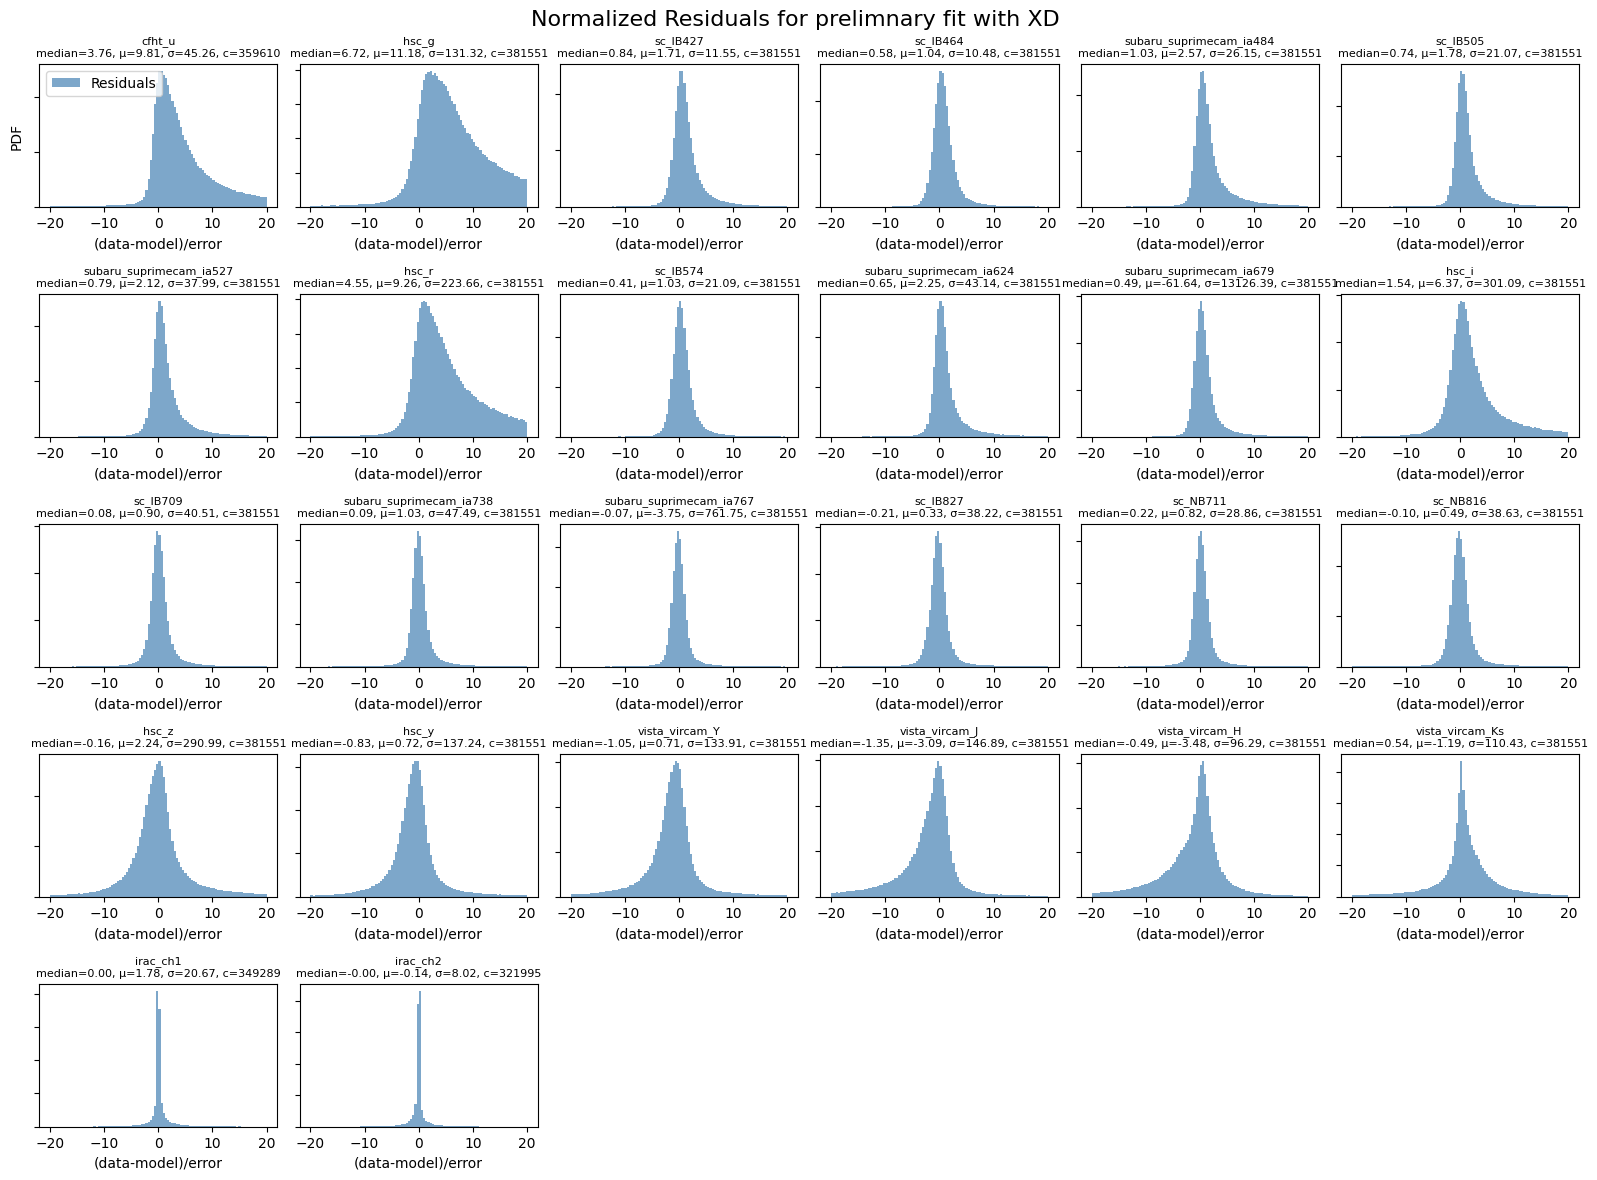

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
from scipy.interpolate import RegularGridInterpolator
from sedpy.observate import load_filters
plt.clf()
filters = load_filters(fil)

fig, axes = plt.subplots(5, 6, figsize=(16, 12))
axes = axes.flatten()
N_bands = len(fil)

all_residuals = [[] for _ in range(N_bands)]

galaxy_coefficients = bi_all

c = f_interp_vec(z)

model_fluxes_batch = np.einsum('nk,nkb->nb', galaxy_coefficients, c)

data_batch = df_flux.to_numpy()
error_batch = df_err.to_numpy()

for i in range(N_bands):
    
    data = data_batch[:, i]
    error = error_batch[:, i]
    model = model_fluxes_batch[:, i]

    mask = np.isfinite(data) & np.isfinite(error) & (error > 1e-6)
    
    data_m = data[mask]
    error_m = error[mask]
    model_m = model[mask]

    r_batch = (data_m - model_m) / error_m
    
    all_residuals[i].append(r_batch)

print("All batches processed. Generating plots...")

for i in range(N_bands):
    ax = axes[i]
    
    if not all_residuals[i]:
        ax.set_title(f"{fil[i]}\nNo valid data")
        continue
        
    r = all_residuals[i]

    ax.hist(r, bins=100, range=(-20,20), density=True, alpha=0.7, color='steelblue', label='Residuals')    
    mu, median, sd, count = np.nanmean(r), np.nanmedian(r), np.nanstd(r), len(r[0])
    ax.set_title(f"{fil[i]}\nmedian={median:.2f}, μ={mu:.2f}, σ={sd:.2f}, c={count}", fontsize=8)
    #ax.set_yscale('log')
    ax.set_xlabel("(data-model)/error")
    ax.set_yticklabels([])
    

axes[0].set_ylabel("PDF")
axes[0].legend()

for j in range(N_bands, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Normalized Residuals for prelimnary fit with XD', fontsize=16)
plt.tight_layout()
plt.show()


# XD with EKF

In [11]:
import numpy as np
from scipy.special import factorial, gamma as func_gamma, gammaincc as func_gammaincc

linewv = np.array([1215.67, 1025.72, 972.537, 949.743, 937.803, 930.748, 926.226,
                    923.150, 920.963, 919.352, 918.129, 917.181, 916.429, 915.824, 915.329, 914.919, 914.576, 914.286, 914.039, 913.826, 913.641, 913.480, 913.339, 913.215, 913.104, 913.006, 912.918, 912.839, 912.768, 912.703, 912.645, 912.592, 912.543, 912.499, 912.458, 912.420, 912.385, 912.353, 912.324])
Rn = np.array([1.00000000e+00, 2.77633136e-01, 1.32485207e-01,
                    7.80473373e-02, 5.15207101e-02, 3.65562130e-02, 
                    2.72721893e-02, 2.11183432e-02, 1.68224852e-02, 
                    1.37159763e-02, 1.13786982e-02, 9.59763314e-03, 
                    8.19526627e-03, 7.07692308e-03, 6.17159763e-03, 
                    5.42840237e-03, 4.80946746e-03, 4.29053254e-03, 
                    3.84911243e-03, 3.47218935e-03, 3.14733728e-03, 
                    2.86568047e-03, 2.61952663e-03, 2.40414201e-03, 
                    2.21183432e-03, 2.04378698e-03, 1.89289941e-03, 
                    1.75798817e-03, 1.63668639e-03, 1.52781065e-03, 
                    1.42899408e-03, 1.33905325e-03, 1.25798817e-03, 
                    1.18343195e-03, 1.11538462e-03, 1.05266272e-03, 
                    9.95266272e-04, 9.42603550e-04, 8.93491124e-04])[:,None]

def tau_eff(z):
    z_1= 1.2593846589041013
    a_1= 1.405759341921824
    A1= 0.01549433546364817
    z_2= 5.174708845486191
    a_2= 3.6336748056970474
    a_3= 7.587297773671628
    delta= 0.030496534844542546
    A2=2.0448040499201565

    return np.piecewise(z,[z<z_1, z>=z_1], [lambda x:A1*((1.+x))**a_1, lambda z:A2*((1.+z)/(1.+z_2))**(a_2)*(0.5*(1.+((1.+z)/(1.+z_2))**(1./delta)))**(delta*(a_3-a_2))])

def tau_eff_highz(z):
    z_2= 5.174708845486191
    a_2= 3.6336748056970474
    a_3= 7.587297773671628
    delta= 0.030496534844542546
    A2=2.0448040499201565
    return A2*((1.+z)/(1.+z_2))**(a_2)*(0.5*(1.+((1.+z)/(1.+z_2))**(1./delta)))**(delta*(a_3-a_2))

def tau_lc_igm(zs, l_obs):
    lratio = l_obs/911.8
    tau_igm = 0.805*lratio**3. * (1/lratio - 1/(1+zs))
    return tau_igm

def tau_lc_lls(zs, l_obs, n0=0.15, beta=1.28, gamma=1.94, nterms = 10):
    lratio = l_obs/911.8 #ratio of observed wavelength to lyman limit, also z_LLS
    zs_p1 = 1+zs
    e_neg1 = 0.36787944117144233  #1/e
    if beta==1.28 and gamma==1.94:
        beta_m1 = 0.28
        gamma_p1 = 2.94
        gam_fn = 0.31340445237536
    else:
        gamma_p1 = gamma + 1
        beta_m1 = beta - 1
        gam_fn = func_gamma(2-beta,1)*func_gammaincc(2-beta,1)
        
    sum1 = _first_lls_sum(beta_m1,nterms)
    sum2 = _second_lls_sum(zs_p1, lratio, gamma_p1=gamma_p1, beta_m1=beta_m1, nterms=nterms)
    tau_lls = n0/(4+gamma-3*beta) * (gam_fn - e_neg1 - sum1) * ( zs_p1**(-3*beta_m1+gamma_p1) * lratio**(3*beta_m1) - np.power(lratio,gamma_p1)) - n0*sum2
    return tau_lls

def _first_lls_sum(beta_m1=0.28, nterms=10):
    #if default beta, nterms return precomputed
    if beta_m1 == 0.28 and nterms==10:
        return -1.3219480209375662
    else:
        # sums from n=0
        n = np.arange(0,nterms)
        return np.sum( (beta_m1) / (n - beta_m1) * (-1)**n / factorial(n) )

def _second_lls_sum(zs_p1, lratio, gamma_p1=2.94, beta_m1=0.28, nterms=10):
    # sums from n=1
    n = np.arange(1,1+nterms)[:,None] 
    if beta_m1 ==0.28 and gamma_p1 == 2.94 and nterms==10:
        gamma_3n_p1 = np.array([ 0.06,  3.06,  6.06,  9.06, 12.06, 15.06, 18.06, 21.06, 24.06,27.06])[:,None]
        term1 = np.array([-6.48148148e+00,  2.65997872e-02, -2.83116547e-03,
         3.46159020e-04, -4.09909024e-05,  4.51444675e-06,
        -4.57762778e-07,  4.27131736e-08, -3.67775581e-09,
         2.93360030e-10])[:,None]
    else:
        gamma_3n_p1 = 3*n - gamma_p1
        term1 = beta_m1 * (-1)**n / ( (gamma_3n_p1) * (n-beta_m1) * factorial(n) )
    term2 = zs_p1**(-gamma_3n_p1) * np.power(lratio, 3*n) - np.power(lratio,gamma_p1)
    return np.sum(term1*term2,axis=0)

def calc_transmission(z_s,l_obs,model='full', nlines = 30, z_lls=None):
    if z_lls is not None:
        if z_lls>z_s:
            raise ValueError('z_lls must be less than or equal to z_s or None')
    if nlines>39:
        raise ValueError('Maximum value for nlines is 39.')
    if model=='full':
        tau_lya = tau_eff
    elif model=='highz':
        tau_lya = tau_eff_highz
    elif model=='optimise':
        zbreak = 1.26
        if np.any(l_obs<zbreak):
            tau_lya = tau_eff
        else:
            tau_lya = tau_eff_highz
    zlook = np.outer(1./linewv[0:nlines],l_obs)-1
    tau_laf_i = np.zeros_like(zlook)
    mask_lya = zlook<z_s
    tau_laf_i[mask_lya] = tau_lya(zlook[mask_lya])
    tau_laf_i *= Rn[0:nlines]
    tau_lys = np.sum(tau_laf_i,axis=0)

    mask_lc = l_obs<911.8*(1.+z_s)
    tau_lc = np.zeros_like(l_obs)
    tau_lc[mask_lc] = tau_lc_igm(z_s,l_obs[mask_lc])

    tau_lls = np.zeros_like(l_obs)
    if z_lls is None:
        tau_lls[mask_lc] += tau_lc_lls(z_s,l_obs[mask_lc])
    else:
        lls_mask = l_obs<(911.8*(1+z_lls))
        tau_lls[lls_mask] = np.inf
    return np.exp(-(tau_lys+tau_lc+tau_lls))


In [281]:
import numpy as np
import pandas as pd
from sedpy.observate import getSED, load_filters
from scipy.interpolate import RegularGridInterpolator
import time
import matplotlib.pyplot as plt
plt.clf()

f_all = np.load('pcaflux_w_redshift_igm.npy')
z_grid1=np.load('zgrid.npy')
f_interp_vec = RegularGridInterpolator((z_grid1,), f_all, bounds_error=False, fill_value=None)

z = df['ez_z_phot'].to_numpy()
mask = np.isfinite(z) & (z<8)
z = z[mask]
Y = np.nan_to_num(df_flux.to_numpy(float), nan=0.0)[mask]
S = np.nan_to_num(df_err.to_numpy(float), nan=1e6)[mask]
R = S**2
N, M = Y.shape

N_bands = len(fil) 
Kc = 4 
theta_new=np.zeros((N,Kc+1)) 
theta_new[:, -1] = np.where(f_ratio > np.median(f_ratio), np.log(0.9/(1-0.9)), np.log(0.3/(1-0.3))) 
M0 = np.mean(alpha3, axis=0) 
#M0 = np.zeros(Kc) 
M1 = np.zeros(Kc) 
mu_eta=np.mean(theta_new[:,-1])

Sigma = np.zeros((Kc+1,Kc+1))
sig = np.cov(alpha3, rowvar=False)
Sigma[:Kc,:Kc]=sig
Sigma[Kc,Kc]=0.3**2

try:
    Sigma_inv = np.linalg.inv(Sigma)
except:
    Sigma_inv = np.linalg.pinv(Sigma)

num_iterations = 20
convergence_threshold = 1e-30
batch_size = 50000
print("\n--- EM for Redshift-Dependent Coeff Mean & Separate Redshift Mean ---")
for it in range(num_iterations):

    start = time.time()
    M0_old, M1_old= M0.copy(), M1.copy()
    mu_eta_old=mu_eta
    theta_old=theta_new.copy()
    theta_new=np.zeros((N,Kc+1))
    theta_new[:,-1]=theta_old[:,-1]
    sum_t = np.zeros((Kc, 1))
    sum_zt = np.zeros((Kc, 1))
    sum_B = np.zeros((Kc+1, Kc+1))
    sum_t_outer = np.zeros((Kc+1, Kc+1))
    sum_eta=0
    #logL = 0.0

    #bi_all = np.zeros((N, Kc+1))   # store full posterior means
    batch_idx = 0
    for b_start in range(0, N, batch_size):
    
        b_end = min(b_start + batch_size, N)
        Yb, Rb = Y[b_start:b_end], R[b_start:b_end]
        zb, zsigb = z[b_start:b_end], z_sigma[b_start:b_end]
        thetab=theta_old[b_start:b_end]
        B = b_end - b_start
    
        Fz = f_interp_vec(zb)
        Rinv = 1.0 / np.maximum(Rb,1e-6)
        eta=thetab[:,-1]
        E=sigmoid(eta)
        b=thetab[:,:-1]
        lam_rest_A = lam_eff_obs_A[None, :] / (1.0 + zb[:, None])
        k_eff = calzetti_k(lam_rest_A)
        trans=10**(-0.4*k_eff*E[:,None])
        pred=trans*np.einsum('bkn,bk->bn', Fz, b)

        C=(trans[:,None,:]*Fz)
        dE_deta = (E * (1.0 - E))                    # (B,)
        dPred_dE = (-0.4*np.log(10.0) * k_eff * pred)  # (B,Nbands)
        M = (dPred_dE * dE_deta[:, None])[:, None, :]  # (B,1,Nbands)
        H = np.concatenate([C, M], axis=1)

        HSH = np.einsum('bkn,bn,bjn->bkj', H, Rinv, H)   
        delta_y = Yb - pred
        HSy = np.einsum('bkn,bn->bk', H, Rinv * delta_y)
        try:
            Bi = np.linalg.inv(HSH + Sigma_inv[None, :, :])
        except:
            Bi = np.linalg.pinv(HSH + Sigma_inv[None, :, :])
            
        mu=M0[None, :] + M1[None, :] * zb[:, None]
        mu_etab=np.full((len(zb), 1), mu_eta)
        mu_full = np.hstack([mu, mu_etab])
        
        rhs = HSy+ np.einsum('kj,bj->bk', Sigma_inv, mu_full - thetab)
        dtheta = np.einsum('bkj,bj->bk', Bi, rhs)

        eta_current = thetab[:, -1]
        deta = dtheta[:, -1]
        alpha = np.ones(len(eta_current))
        
        soft_floor = np.log(0.001/(1-0.001))  
        ceil = np.log(0.999/(1-0.999))
        
        mask = (eta_current + deta < soft_floor) & (deta != 0)
        alpha[mask] = (soft_floor - eta_current[mask]) / deta[mask]

        mask_ceil = (eta_current + deta > ceil) & (deta != 0)
        alpha[mask_ceil] = (ceil - eta_current[mask_ceil]) / deta[mask_ceil]
        
        theta_newb = thetab +  alpha[:, None] * dtheta
        theta_new[b_start:b_end]=theta_newb

        sum_t += np.sum(theta_newb[:,:-1], axis=0, keepdims=True).T
        sum_eta += np.sum(theta_newb[:,-1])
        sum_zt += np.sum(zb[:, None] * theta_newb[:,:-1], axis=0, keepdims=True).T
        sum_B += np.sum(Bi, axis=0)
        sum_t_outer += np.einsum('bi,bj->ij', theta_newb, theta_newb)
        #sum_E_outer += np.einsum('b,b->bb', theta_newb[:,-1], theta_newb[:,-1])
    
    sum_z = np.sum(z)
    sum_z2 = np.sum(z**2)

    A_reg = np.array([[N, sum_z], [sum_z, sum_z2]])
    try:
        A_reg_inv = np.linalg.inv(A_reg)
    except:
        A_reg_inv = np.linalg.pinv(A_reg)

    rhs2 = np.vstack([sum_t.T, sum_zt.T])

    M0, M1 = (A_reg_inv @ rhs2)
    
    mu_eta = np.mean(theta_new[:, -1])
    mu_final_b = M0[None, :] + M1[None, :] * z[:, None]
    mu_final_eta = np.full((N, 1), mu_eta)
    mu_final = np.hstack([mu_final_b, mu_final_eta])
    
    # Efficient Sigma Update
    # (theta_outer and B are already accumulated)
    sum_mu_theta = np.einsum('bi,bj->ij', mu_final, theta_new)
    sum_mu_mu = np.einsum('bi,bj->ij', mu_final, mu_final)
    
    Sigma = (sum_B + sum_t_outer - sum_mu_theta - sum_mu_theta.T + sum_mu_mu) / N
    
    try:
        Sigma_inv = np.linalg.inv(Sigma)
    except:
        Sigma_inv = np.linalg.pinv(Sigma)
        
    delta_M = np.linalg.norm(M0 - M0_old) + np.linalg.norm(M1 - M1_old) 
    print(f"Iter {it+1:02d} | ΔM = {delta_M:.3e} | E Mean: {sigmoid(mu_eta)}")
    end = time.time()
    
    if delta_M < convergence_threshold:
        print("Converged.")
        break

print("\n--- Fit Complete ---")
print("Final M0c:", M0)
print("Final M1c:", M1)
print("Final mu E:", mu_eta)
print("Final Sigma:", Sigma)
#plt.figure(logL)
        
        


C:\Users\pranav\AppData\Local\Temp\ipykernel_5896\1026718249.py:34: RuntimeWarning: divide by zero encountered in divide
  f_ratio = flux_red / flux_blue
C:\Users\pranav\AppData\Local\Temp\ipykernel_5896\1026718249.py:34: RuntimeWarning: invalid value encountered in divide
  f_ratio = flux_red / flux_blue



--- EM for Redshift-Dependent Coeff Mean & Separate Redshift Mean ---
Iter 01 | ΔM = 3.060e+06 | E Mean: 0.30000000000000004
Iter 02 | ΔM = 6.583e+00 | E Mean: 0.4525046427959139
Iter 03 | ΔM = 2.962e+00 | E Mean: 0.5394901065673328
Iter 04 | ΔM = 7.576e-01 | E Mean: 0.544175679624203
Iter 05 | ΔM = 3.132e-01 | E Mean: 0.5483059379842891
Iter 06 | ΔM = 2.571e-01 | E Mean: 0.5536295023833501
Iter 07 | ΔM = 1.323e-01 | E Mean: 0.5614754142326597
Iter 08 | ΔM = 5.378e-02 | E Mean: 0.5690274099934497
Iter 09 | ΔM = 1.917e-02 | E Mean: 0.5692390259740576
Iter 10 | ΔM = 1.594e-02 | E Mean: 0.5667132645861059
Iter 11 | ΔM = 8.813e-03 | E Mean: 0.5616281469643634
Iter 12 | ΔM = 3.459e-03 | E Mean: 0.5638850790984071
Iter 13 | ΔM = 4.436e-03 | E Mean: 0.5604737870239666
Iter 14 | ΔM = 8.460e-04 | E Mean: 0.5621052188189049
Iter 15 | ΔM = 2.484e-03 | E Mean: 0.5576932664029621
Iter 16 | ΔM = 5.731e-04 | E Mean: 0.557331650118159
Iter 17 | ΔM = 4.326e-03 | E Mean: 0.5542822081316064
Iter 18 | ΔM

<Figure size 640x480 with 0 Axes>

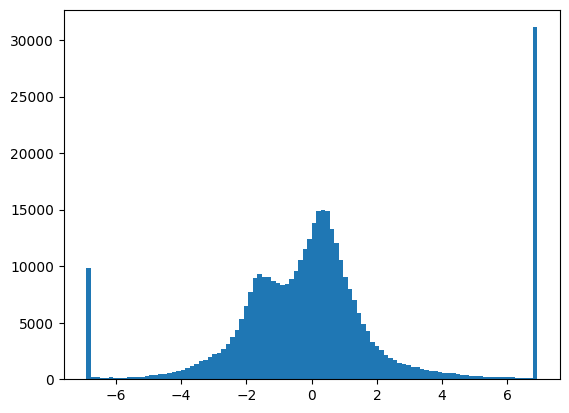

In [282]:
plt.hist(theta_new[:,-1],bins=100)
plt.show()

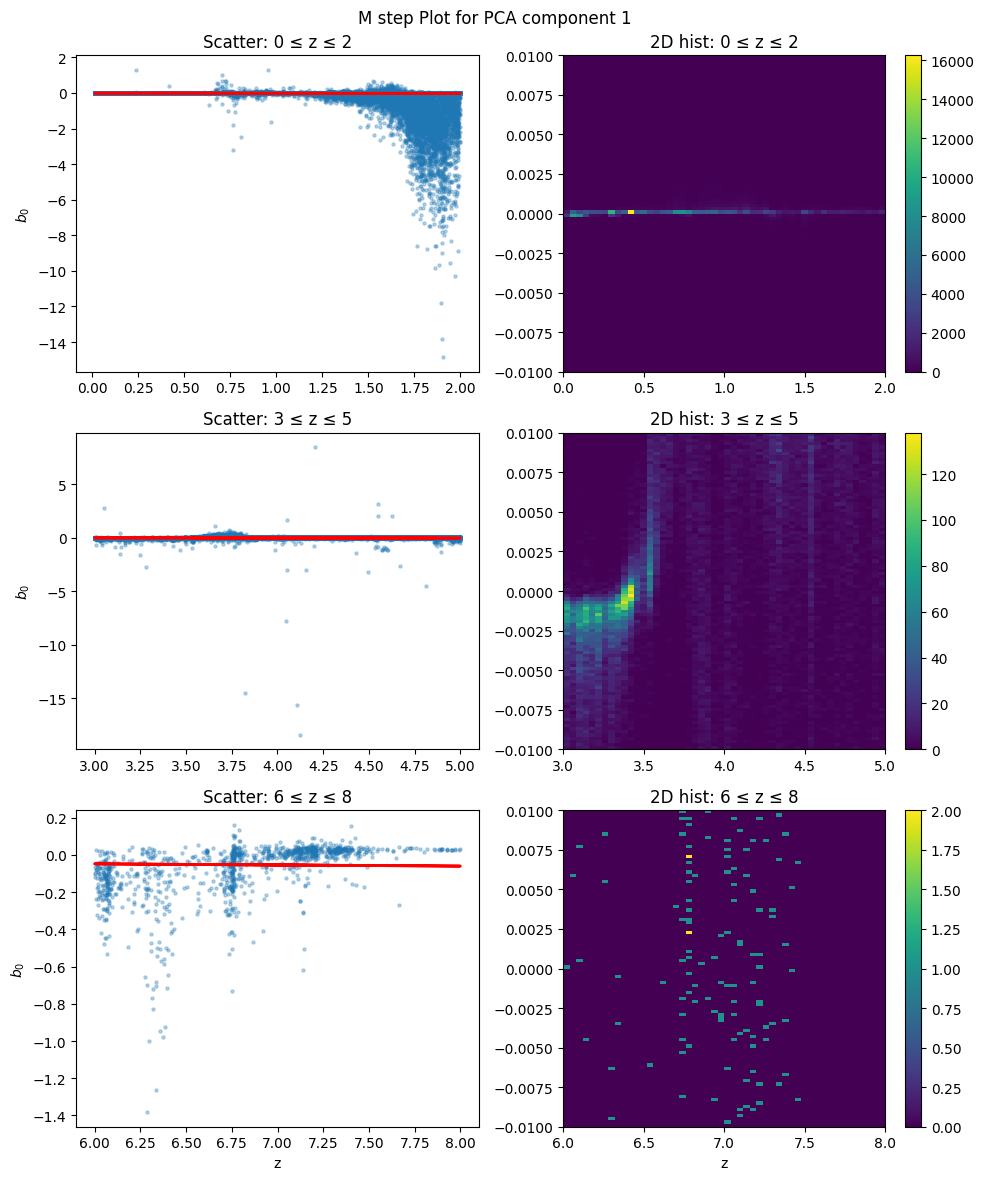

In [231]:
import numpy as np
import matplotlib.pyplot as plt

# Redshift bins: (zmin, zmax)
z_bins = [(0, 2,0.01,-0.01), (3, 5,0.01,-0.01), (6, 8,0.01,-0.01)]
fig, axes = plt.subplots(
    nrows=3, ncols=2,
    figsize=(10, 12),
    sharex=False, sharey=False
)
s=0
for i, (zmin, zmax,ymax,ymin) in enumerate(z_bins):

    mask = (z >= zmin) & (z <= zmax)

    z_sel = z[mask]
    b_sel = theta_new[mask, s]

    # --- Column 1: scatter ---
    ax_scatter = axes[i, 0]
    ax_scatter.scatter(z_sel, b_sel, s=5, alpha=0.3)
    ax_scatter.set_ylabel(rf"$b_{s}$")
    ax_scatter.set_title(f"Scatter: {zmin} ≤ z ≤ {zmax}")

    # --- Column 2: 2D histogram ---
    ax_hist = axes[i, 1]
    h = ax_hist.hist2d(z_sel, b_sel,bins=[50, 100],cmap="viridis",range=[[zmin, zmax], [ymin, ymax]])
    ax_scatter.plot(z_sel,M0[s]+M1[s]*z_sel,'r',lw=2)
    ax_hist.plot(z_sel,M0[s]+M1[s]*z_sel,'r',lw=2,alpha=1)
    ax_hist.set_title(f"2D hist: {zmin} ≤ z ≤ {zmax}")
    plt.colorbar(h[3], ax=ax_hist)

# X-labels only on bottom row
axes[-1, 0].set_xlabel("z")
axes[-1, 1].set_xlabel("z")
plt.suptitle(f'M step Plot for PCA component {s+1}')
plt.tight_layout()
plt.show()


# JP model verification

In [209]:
M0,M1,Sigma

(array([-0.00433603,  0.00375123, -0.00921651,  0.00328557]),
 array([-0.00309421,  0.00166437, -0.01415205,  0.00512875]),
 array([[ 0.01593384, -0.00776221,  0.02697557, -0.00944376, -0.03077805],
        [-0.00776221,  0.00529997, -0.01402796,  0.0047595 ,  0.02121498],
        [ 0.02697557, -0.01402796,  0.06782088, -0.02362572, -0.0664184 ],
        [-0.00944376,  0.0047595 , -0.02362572,  0.00825395,  0.02309282],
        [-0.03077805,  0.02121498, -0.0664184 ,  0.02309282,  0.76329897]]))

In [127]:
M0_JP=np.array([-5.81670704e-05, -3.50341228e-05,  7.42786782e-04, -2.65968300e-04])

M1_JP= np.array([ 1.45758869e-04,  5.38199532e-06, -1.00356455e-03,  3.85206107e-04])


Sigma_JP= [[ 1.33210502e-03, -1.19703157e-05,  2.68230638e-03,
         -1.00715337e-03],
        [-1.19703157e-05,  4.96200688e-07, -2.39287040e-05,
          9.00930629e-06],
        [ 2.68230638e-03, -2.39287040e-05,  5.46480391e-03,
         -2.05346140e-03],
        [-1.00715337e-03,  9.00930629e-06, -2.05346140e-03,
          7.71685819e-04]]

In [243]:
# Use the full augmented dimension (Kc + 1)
L = Kc + 1 
all_posterior_means = np.zeros((N, L))
all_posterior_covs = np.zeros((N, L, L))

# Pre-compute Sigma_inv once
Sigma_inv = np.linalg.inv(Sigma + np.eye(L)*1e-8)

for b_start in range(0, N, batch_size):
    b_end = min(b_start + batch_size, N)
    Yb, Rb, zb = Y[b_start:b_end], R[b_start:b_end], z[b_start:b_end]
    
    # 1. Use the values from your final 'theta' array to get the dust
    # theta_final should be the 'theta_new' from your last EM iteration
    E_final = theta_new[b_start:b_end, -1]
    
    # 2. Reconstruct the attenuated Jacobian H = [C | M]
    Fz = f_interp_vec(zb)
    trans = 10**(-0.4 * k_vec[None, :] * E_final[:, None])
    pred = trans * np.einsum('bkn,bk->bn', Fz, theta_new[b_start:b_end, :-1])
    
    C = trans[:, None, :] * Fz
    M = (-np.log(10) * 0.4 * k_vec[None, :] * pred)[:, None, :]
    H = np.concatenate([C, M], axis=1) # Full 5-column Jacobian

    # 3. Posterior Covariance Bi (The full 5x5 matrix)
    Rinv = 1.0 / np.maximum(Rb, 1e-6)
    HSH = np.einsum('bkn,bn,bjn->bkj', H, Rinv, H)
    Bi = np.linalg.inv(HSH + Sigma_inv[None, :, :])

    # 4. Posterior Mean (Full 5D vector: [b1, b2, b3, b4, E])
    mu_full = np.hstack([M0[None, :] + M1[None, :] * zb[:, None], 
                         np.full((len(zb), 1), mu_E)])
    
    delta_y = Yb - pred
    HSy = np.einsum('bkn,bn->bk', H, Rinv * delta_y)
    rhs = HSy + np.einsum('kj,bj->bk', Sigma_inv, mu_full - theta_new[b_start:b_end])
    
    # This gives the final refined [coefficients, dust]
    all_posterior_means[b_start:b_end] = theta_new[b_start:b_end] + np.einsum('bij,bj->bi', Bi, rhs)
    all_posterior_covs[b_start:b_end] = Bi

# Separate them for your science analysis
galaxy_coefficients = all_posterior_means[:, :-1] # (N, 4)
galaxy_dust = all_posterior_means[:, -1]         # (N,)
galaxy_dust_err = np.sqrt(all_posterior_covs[:, -1, -1]) # Uncertainties!

In [219]:
Sigma_c_inv.shape

(1, 4, 4)

In [215]:
mu_i.shape

(5000, 4)

In [244]:
galaxy_coefficients

array([[ 3.24413716e-08, -1.55722931e-06,  2.84476841e-06,
         3.36892837e-06],
       [ 3.57496800e-07, -7.41475561e-07, -6.71505193e-07,
         1.77555899e-06],
       [ 2.28713068e-03, -3.86224086e-04, -2.76395423e-03,
         1.11402666e-03],
       ...,
       [ 2.70754084e-03, -4.48861810e-03, -3.63865657e-02,
         1.80388192e-02],
       [ 1.58921804e-05, -3.07071204e-05, -3.68636610e-05,
         9.97673998e-05],
       [ 9.29078305e-04, -5.99125335e-04, -1.91234284e-03,
         1.09197832e-03]])

All batches processed. Generating plots...


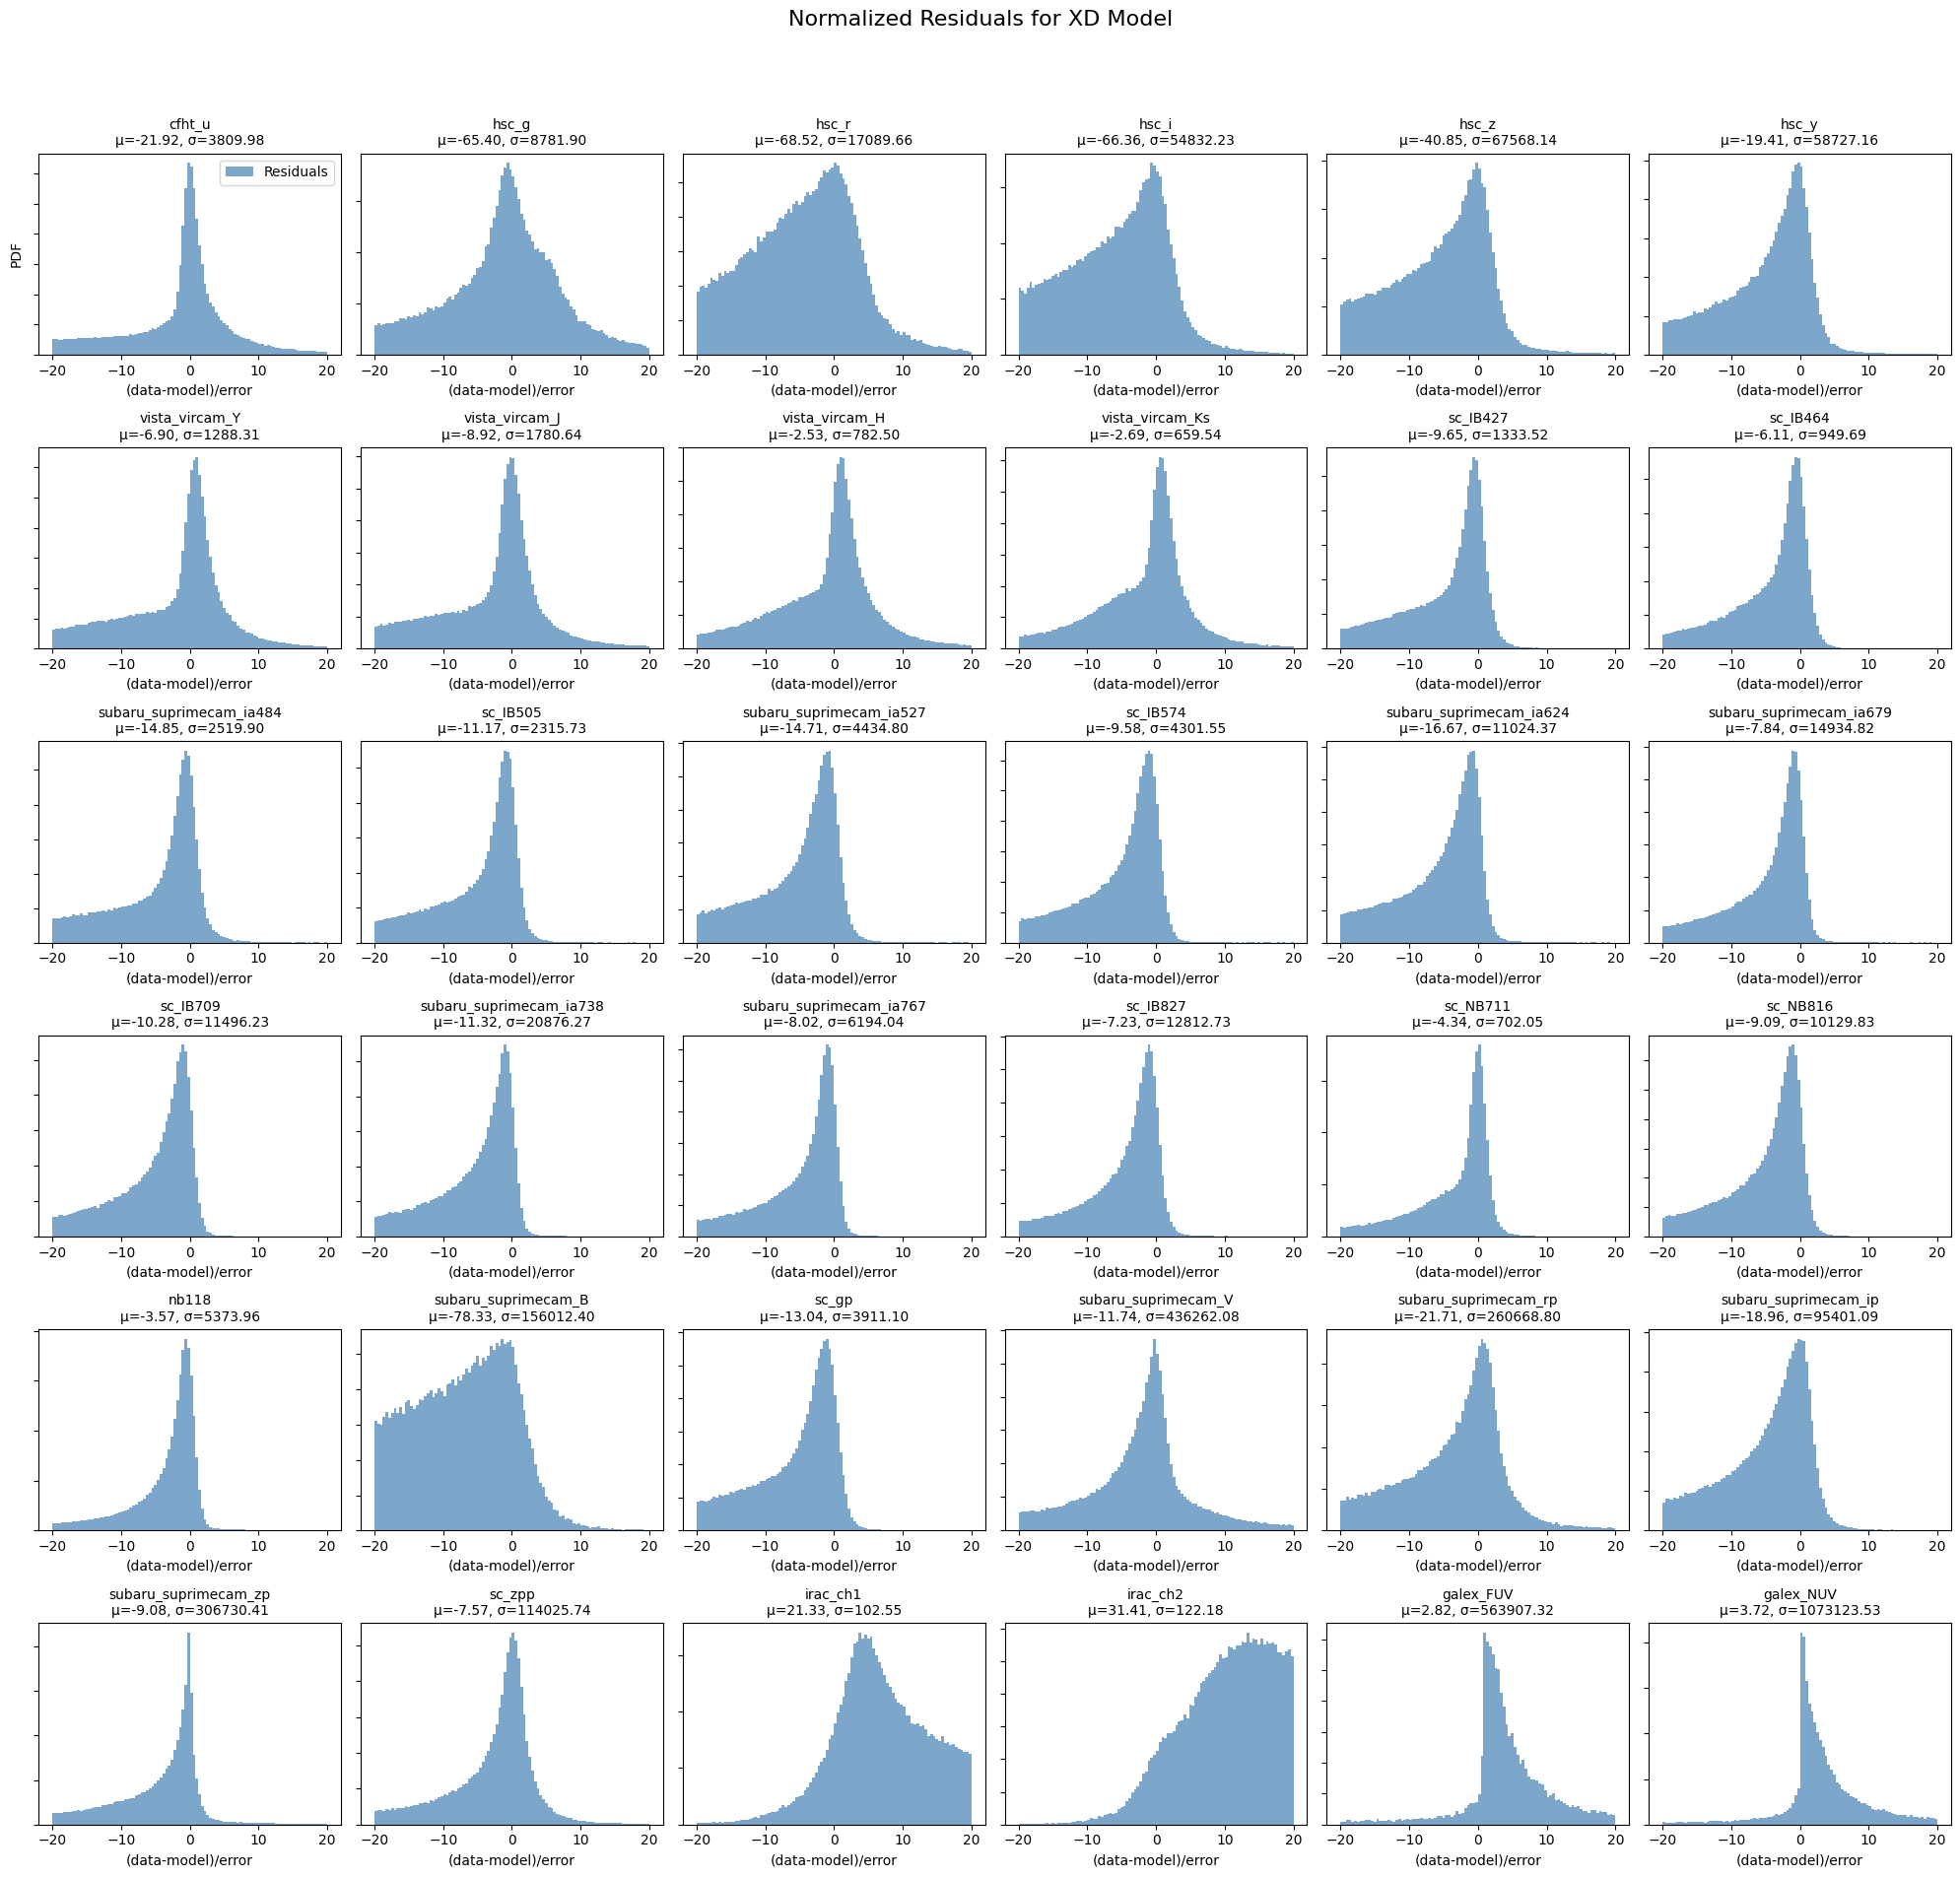

In [245]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
from scipy.interpolate import RegularGridInterpolator
from sedpy.observate import load_filters

filters = load_filters(fil)

batch_size = 50000

fig, axes = plt.subplots(6, 6, figsize=(20, 20))
axes = axes.flatten()
N_bands = len(fil)


if len(axes) < N_bands:
    N_bands_to_plot = len(axes)
else:
    N_bands_to_plot = N_bands

all_residuals = [[] for _ in range(N_bands_to_plot)]

for b_start in range(0, N, batch_size):
    b_end = min(b_start + batch_size, N)
    B = b_end - b_start

    z_batch = z[b_start:b_end]
    galaxy_coefficients_batch = galaxy_coefficients[b_start:b_end]
    
    c_batch = f_interp_vec(z_batch)

    model_fluxes_batch = np.einsum('nk,nkb->nb', galaxy_coefficients_batch, c_batch)
    
    data_batch = df_flux.iloc[b_start:b_end, :N_bands_to_plot].to_numpy()
    error_batch = df_err.iloc[b_start:b_end].to_numpy()

    for i in range(N_bands_to_plot):
        
        data = data_batch[:, i]
        error = error_batch[:, i]
        model = model_fluxes_batch[:, i]

        mask = np.isfinite(data) & np.isfinite(error) & (error > 1e-6)
        
        data_m = data[mask]
        error_m = error[mask]
        model_m = model[mask]

        if len(data_m) == 0:
            continue

        r_batch = (data_m - model_m) / error_m
        
        all_residuals[i].append(r_batch)

print("All batches processed. Generating plots...")

for i in range(N_bands_to_plot):
    ax = axes[i]
    
    if not all_residuals[i]:
        ax.set_title(f"{fil[i]}\nNo valid data")
        continue
        
    r = np.concatenate(all_residuals[i])

    ax.hist(r, bins=100, range=(-20,20), density=True, alpha=0.7, color='steelblue', label='Residuals')    
    mu, sd = np.nanmedian(r), np.nanstd(r)
    ax.set_title(f"{fil[i]}\nμ={mu:.2f}, σ={sd:.2f}", fontsize=10)
    #ax.set_yscale('log')
    ax.set_xlabel("(data-model)/error")
    ax.set_yticklabels([])
    

axes[0].set_ylabel("PDF")
axes[0].legend()

for j in range(N_bands_to_plot, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Normalized Residuals for XD Model', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('residuals.png')
plt.show()



<>:83: SyntaxWarning: invalid escape sequence '\c'
<>:92: SyntaxWarning: invalid escape sequence '\c'
<>:83: SyntaxWarning: invalid escape sequence '\c'
<>:92: SyntaxWarning: invalid escape sequence '\c'
C:\Users\pranav\AppData\Local\Temp\ipykernel_8488\4152856673.py:83: SyntaxWarning: invalid escape sequence '\c'
  color='orange', alpha=0.7, label='Reduced $\chi^2$')
C:\Users\pranav\AppData\Local\Temp\ipykernel_8488\4152856673.py:92: SyntaxWarning: invalid escape sequence '\c'
  plt.title(f'Distribution of Reduced $\chi^2$')


Processing batches...


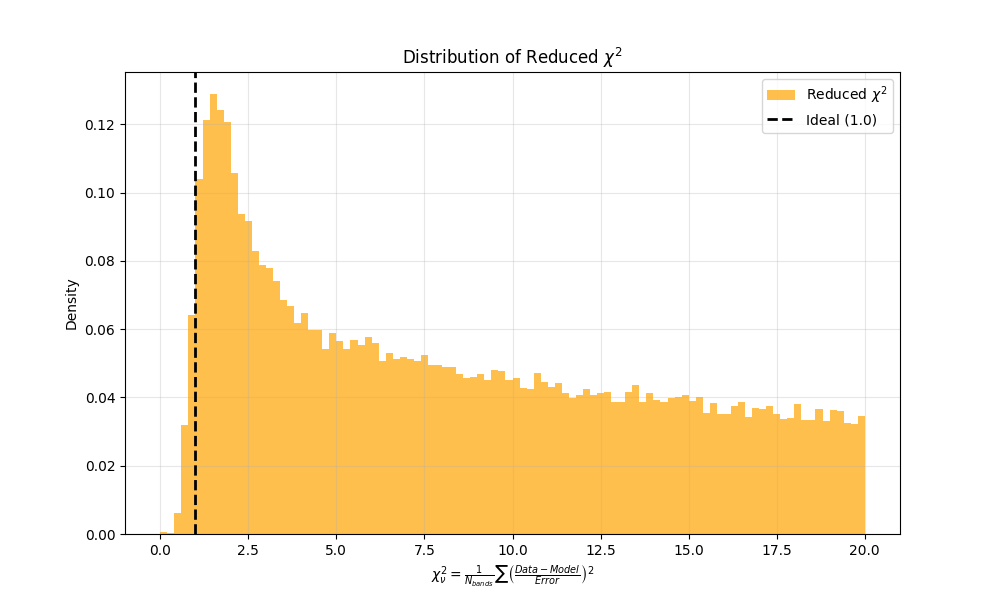

In [132]:
import numpy as np
import matplotlib.pyplot as plt

# Lists to store the final reduced chi2 values
chi2_reduced_all = []

all_residuals = [[] for _ in range(N_bands_to_plot)]

print("Processing batches...")

for b_start in range(0, N, batch_size):
    b_end = min(b_start + batch_size, N)
    
    # 1. Load Data for Batch
    z_batch = z[b_start:b_end]
    galaxy_coefficients_batch = galaxy_coefficients[b_start:b_end]
    data_batch = df_flux.iloc[b_start:b_end, :N_bands_to_plot].to_numpy()
    error_batch = df_err.iloc[b_start:b_end, :N_bands_to_plot].to_numpy()
    
    # 2. Calculate Model
    c_batch = f_interp_vec(z_batch) # (Batch, Kc, Bands)
    model_fluxes_batch = np.einsum('nk,nkb->nb', galaxy_coefficients_batch, c_batch)

    # --- NEW CODE: CALCULATE CHI SQUARED PER GALAXY ---
    
    # Calculate residuals for the whole matrix at once
    # Add small epsilon to error to avoid division by zero
    diff = (data_batch - model_fluxes_batch)
    norm_resid = diff / (error_batch)
    
    # Identify valid data (Same logic as your loop)
    # We want to ignore NaNs, Infs, and zero-errors in the sum
    valid_mask = np.isfinite(data_batch) & np.isfinite(error_batch) & (error_batch > 1e-6)
    
    # Square the residuals
    chi2_matrix = norm_resid ** 2
    
    # Zero out the invalid data points so they don't add to the sum
    chi2_matrix[~valid_mask] = 0.0
    
    # Sum across bands (axis=1) to get total Chi2 per galaxy
    chi2_per_galaxy = np.sum(chi2_matrix, axis=1)
    
    # Count how many valid bands each galaxy had (Degrees of Freedom)
    dof_per_galaxy = np.sum(valid_mask, axis=1)
    
    # Calculate Reduced Chi2 (Chi2 / DoF)
    # Handle division by zero for galaxies with 0 valid bands
    chi2_red_batch = np.divide(chi2_per_galaxy, dof_per_galaxy, 
                               out=np.zeros_like(chi2_per_galaxy), 
                               where=dof_per_galaxy!=0)
    
    # Store it
    chi2_reduced_all.append(chi2_red_batch)
    # --------------------------------------------------

    # (Your existing loop for per-band residuals plots remains here)
    for i in range(N_bands_to_plot):
        data = data_batch[:, i]
        error = error_batch[:, i]
        model = model_fluxes_batch[:, i]
        mask = np.isfinite(data) & np.isfinite(error) & (error > 1e-6)
        
        if np.sum(mask) == 0: continue
            
        data_m = data[mask]
        error_m = error[mask]
        model_m = model[mask]
        r_batch = (data_m - model_m) / error_m
        all_residuals[i].append(r_batch)

# --- Combine and Plot Chi-Squared ---

# Flatten the list of arrays
final_chi2_red = np.concatenate(chi2_reduced_all)

# Plot the histogram
plt.figure(figsize=(10, 6))

# Using a range of 0 to 10 because reduced chi2 should be around 1
# If it is huge, the plot will look empty, so we clamp the range.
plt.hist(final_chi2_red, bins=100, range=(0, 20), density=True, 
         color='orange', alpha=0.7, label='Reduced $\chi^2$')

# Add a line at 1.0 (Theoretical perfect fit)
plt.axvline(1.0, color='k', linestyle='--', linewidth=2, label='Ideal (1.0)')

# Calculate stats
median_chi2 = np.median(final_chi2_red)
mean_chi2 = np.mean(final_chi2_red)

plt.title(f'Distribution of Reduced $\chi^2$')
plt.xlabel(r'$\chi^2_{\nu} = \frac{1}{N_{bands}} \sum \left( \frac{Data-Model}{Error} \right)^2$')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)

# Save or Show
plt.savefig('chi_squared_distribution.png')
plt.show()

C:\Users\pranav\AppData\Local\Temp\ipykernel_13480\1473369133.py:42: RuntimeWarning: divide by zero encountered in log10
  mag=23.9-2.5*np.log10(model)
C:\Users\pranav\AppData\Local\Temp\ipykernel_13480\1473369133.py:42: RuntimeWarning: invalid value encountered in log10
  mag=23.9-2.5*np.log10(model)
C:\Users\pranav\AppData\Local\Temp\ipykernel_13480\1473369133.py:43: RuntimeWarning: invalid value encountered in log10
  data_mag=23.9-2.5*np.log10(data)


All batches processed. Generating plots...


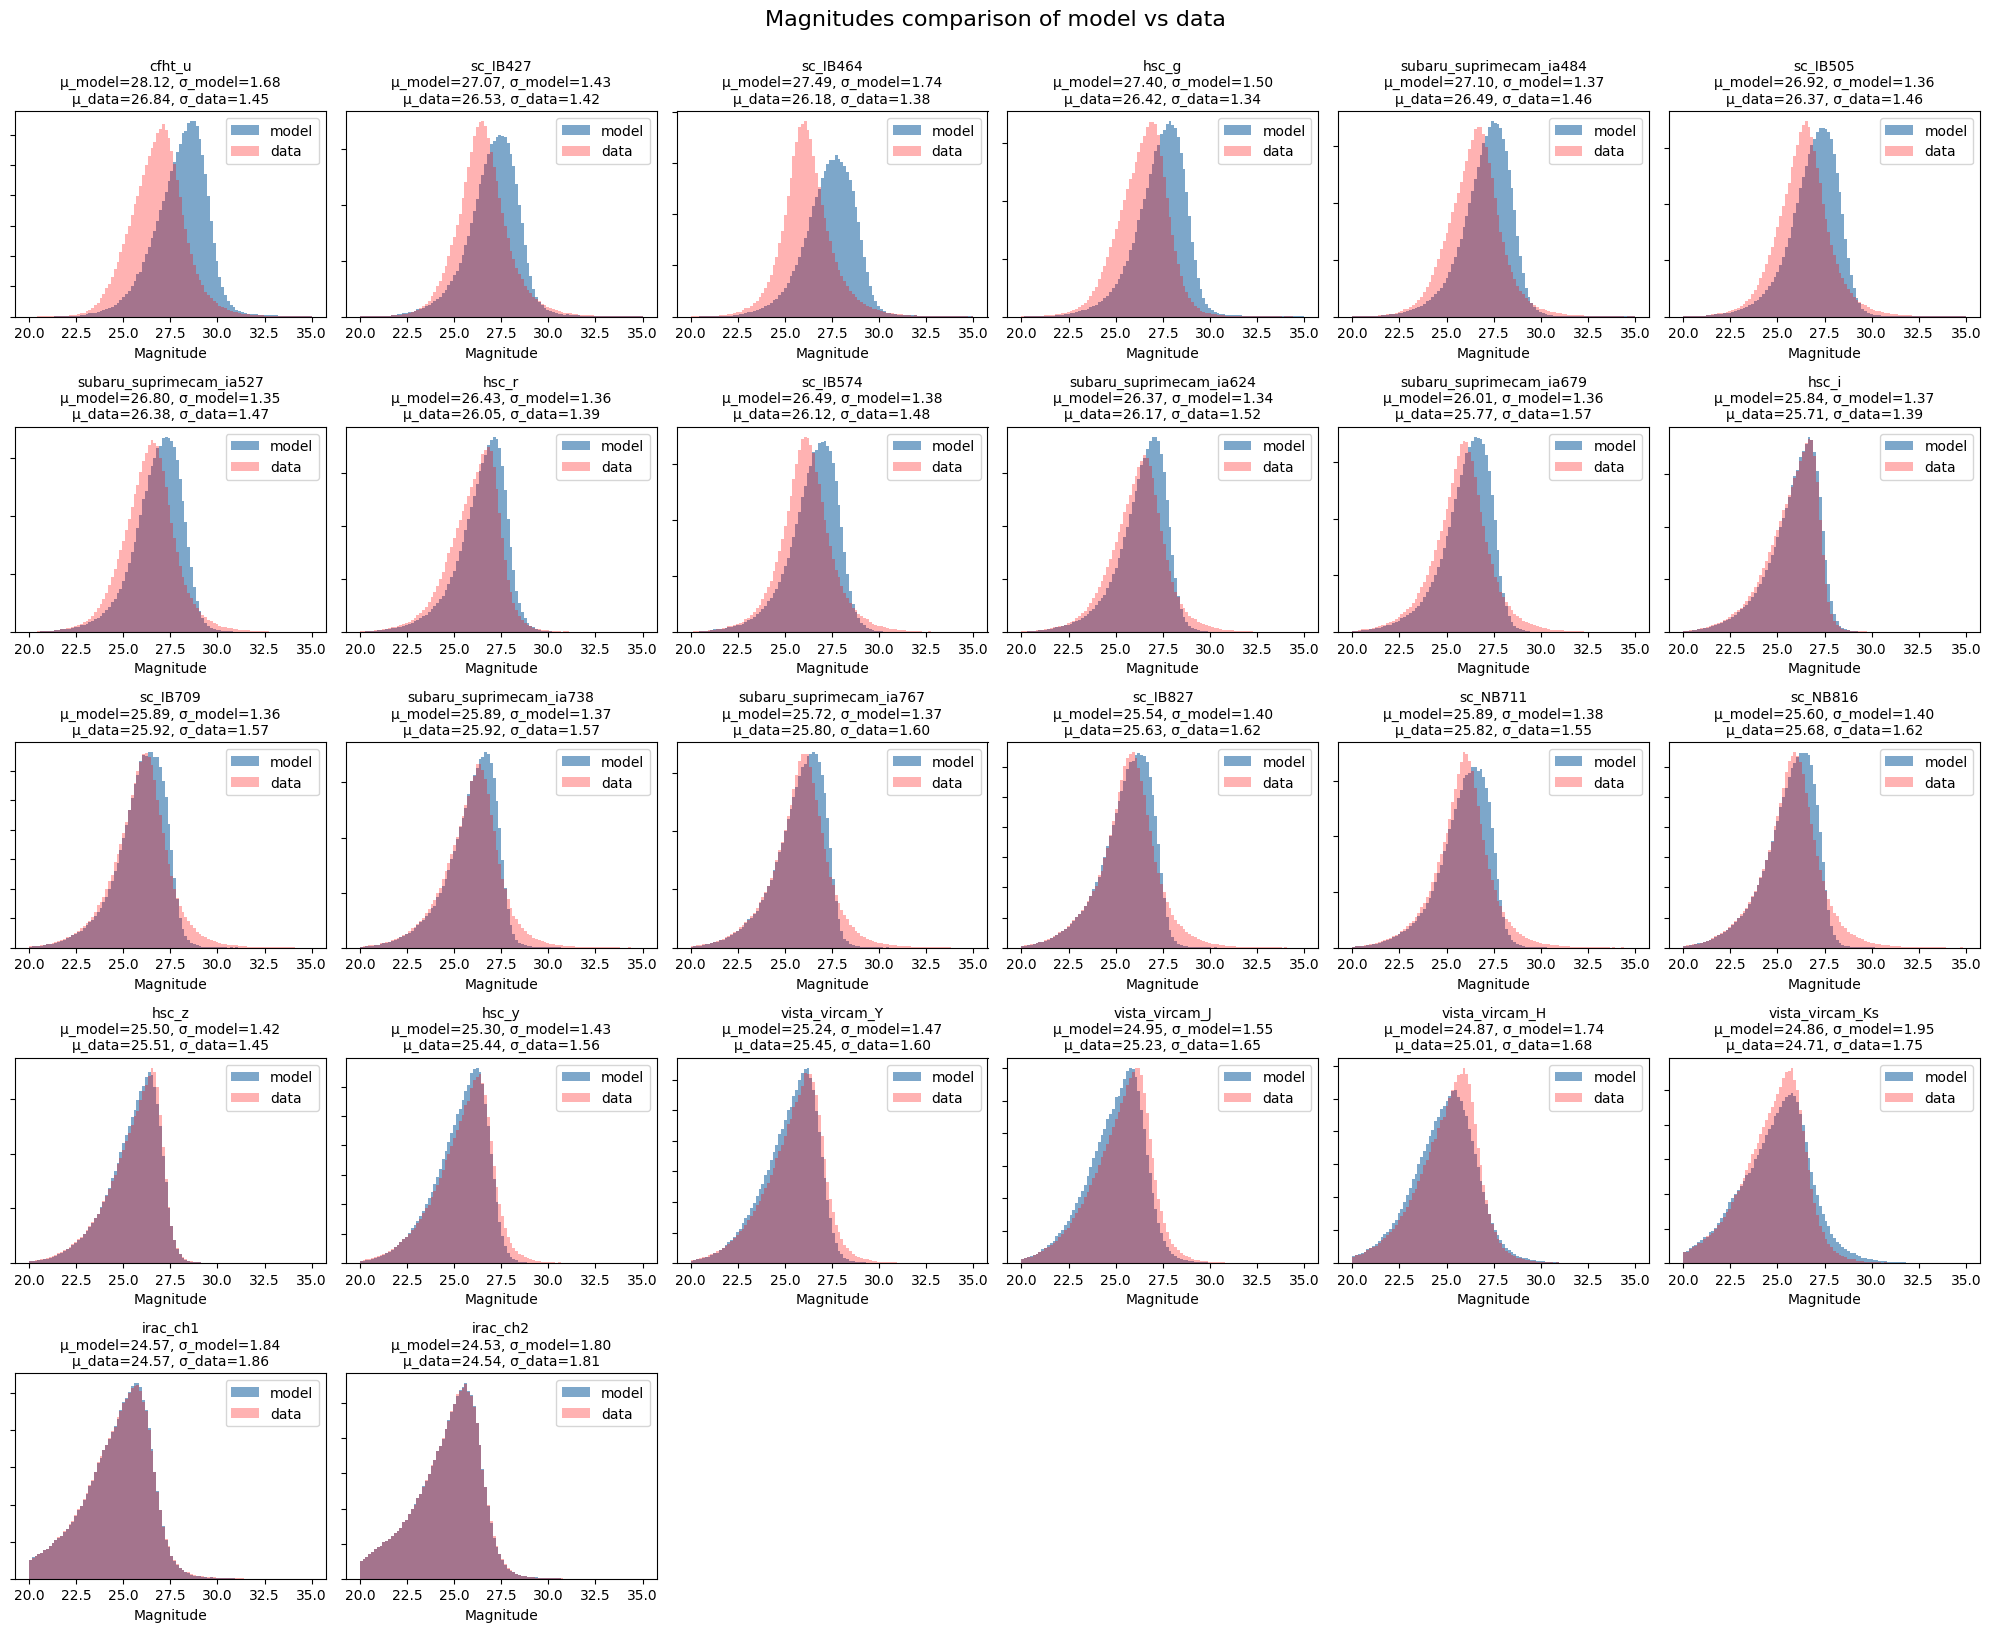

In [66]:

batch_size = 50000

fig, axes = plt.subplots(6, 6, figsize=(20, 20))
axes = axes.flatten()

N_bands = len(fil)

if len(axes) < N_bands:
    N_bands_to_plot = len(axes)
else:
    N_bands_to_plot = N_bands

mags = [[] for _ in range(N_bands_to_plot)]
data_mags = [[] for _ in range(N_bands_to_plot)]

for b_start in range(0, N, batch_size):
    b_end = min(b_start + batch_size, N)
    B = b_end - b_start

    z_batch = z[b_start:b_end]
    galaxy_coefficients_batch = galaxy_coefficients[b_start:b_end]
    
    c_batch = f_interp_vec(z_batch)
    data_batch = df_flux.iloc[b_start:b_end, :N_bands_to_plot].to_numpy()
    model_fluxes_batch = np.einsum('nk,nkb->nb', galaxy_coefficients_batch, c_batch)
    
    #data_batch = df3.iloc[b_start:b_end, :N_bands_to_plot].to_numpy()
    #error_batch = df_err.iloc[b_start:b_end, :N_bands_to_plot].to_numpy()

    for i in range(N_bands_to_plot):
        
        #data = data_batch[:, i]
        #error = error_batch[:, i]
        model = model_fluxes_batch[:, i]
        data=data_batch[:,i]
        #mask = np.isfinite(data) & np.isfinite(error) & (error > 1e-6)
        
        #data_m = data[mask]
        #error_m = error[mask]
        #model_m = model[mask]

        mag=23.9-2.5*np.log10(model)
        data_mag=23.9-2.5*np.log10(data)
        mask=np.isfinite(mag)&np.isfinite(data_mag)
        mag=mag[mask]
        data_mag=data_mag[mask]
        mags[i].append(mag)
        data_mags[i].append(data_mag)

print("All batches processed. Generating plots...")

for i in range(N_bands_to_plot):
    ax = axes[i]
    
    if not all_residuals[i]:
        ax.set_title(f"{fil[i]}\nNo valid data")
        continue
    r=np.concatenate(mags[i])
    p=np.concatenate(data_mags[i])
    

    ax.hist(r, bins=100, range=(20,35), density=True, alpha=0.7, color='steelblue', label='model') 
    ax.hist(p, bins=100, range=(20,35), density=True, alpha=0.3, color='red', label='data')  
    mu, sd = np.mean(r), np.std(r)
    mu_d, sd_d = np.mean(p), np.std(p)
    ax.set_title(f"{fil[i]}\nμ_model={mu:.2f}, σ_model={sd:.2f}\nμ_data={mu_d:.2f}, σ_data={sd_d:.2f}", fontsize=10)
    
    ax.set_xlabel("Magnitude")
    ax.set_yticklabels([])
    ax.legend()



for j in range(N_bands_to_plot, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Magnitudes comparison of model vs data', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()


In [65]:
# --- Ordinary least squares (a1) ---
# a1[i] = Y[i] @ pinv(Fz[i])
alpha1 = np.einsum('bm,bmk->bk', Y, np.linalg.pinv(Fz))   # (B,Kc)

# --- Normal equation form (a2) ---
# a2[i] = Y[i] @ Fz[i].T @ inv(Fz[i] @ Fz[i].T)
FFt = np.einsum('bkm,bjm->bkj', Fz, Fz)                   # (B,Kc,Kc)
FFt_inv = np.linalg.pinv(FFt)
alpha2 = np.einsum('bm,bkm,bkj->bk', Y, Fz, FFt_inv)      # (B,Kc)

# --- Weighted least squares (a3) ---
# a3[i] = Y[i] @ diag(Rinv[i]) @ Fz[i].T @ inv(Fz[i] @ diag(Rinv[i]) @ Fz[i].T)
FRF = np.einsum('bkm,bm,bjm->bkj', Fz, Rinv, Fz)           # Fz diag(Rinv) Fz^T
FRF_inv = np.linalg.pinv(FRF)
alpha3 = np.einsum('bm,bm,bkm,bkj->bk', Y, Rinv, Fz, FRF_inv)


In [66]:
np.save('alpha1.npy',alpha1)
np.save('alpha2.npy',alpha2)
np.save('alpha3.npy',alpha3)